# RF Explorer Calibration

A well known issue in the 2021 MWA beam paper is that the attenuation in the MWA (AUT) side of this signal chain was set too low, and the brightest signals saturated. We attempted to correct for this compression, but it wasn't good enough. Looking at the raw data, it appears that the primary lobe often has a 3dB deficit in measured power, this is 50% in linear units! This notebook is an effort to do better

In [1]:
import os
import json
from pathlib import Path

import numpy as np
import healpy as hp
import cmasher as cmr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap as LSC
from scipy.stats import median_abs_deviation as mad
from scipy.stats import binned_statistic, beta
from scipy.optimize import minimize

colors = cmr.pride(np.linspace(0.1, 0.8, 256))
colors[0] = mcolors.to_rgba("whitesmoke")
prd = ListedColormap(colors, name="pride")
prd.set_under("whitesmoke")

### Let's first try and recreate Fig 9 from the paper

In [2]:
rfe_cali_dir = Path("../passes/rfe_cal/original")
# rfe_cali_dir = Path("../passes/rfe_cal/rfe_calibration_5hz/")
gain_files = sorted(rfe_cali_dir.glob("*.json"))

# Combine data from all RF Explorers
pass_data = []
pass_resi = []
# pass_hpx = []

for f in (gain_files):
    with open(f, "r") as data:
        rfe = json.load(data)
        # pass_data.extend(rfe["tile_pass_data"])
        pass_data.extend(rfe["pass_data"])
        pass_resi.extend(rfe["pass_resi"])
        
pass_data = np.array(pass_data)
pass_resi = np.array(pass_resi)

# Clean up any nans, infs
mask = np.isfinite(pass_data) & np.isfinite(pass_resi)
pass_data = pass_data[mask]
pass_resi = pass_resi[mask]
# pass_hpx = pass_hpx[mask]

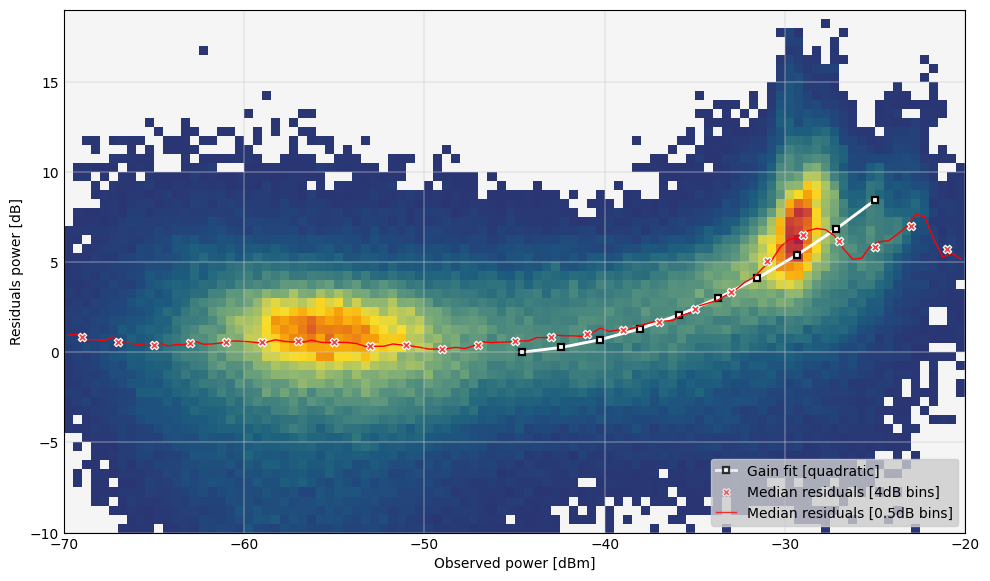

In [3]:
gain_cali_start = -50
gain_cali_stop = -30
data_xlims = (-70, -20)
data_ylims = (-10, 19)

# Crop data - limit to sensible x-range
mask_crop = (
    (pass_data <= data_xlims[1]) & (pass_data >= data_xlims[0])
    & (pass_resi <=data_ylims[1]) & (pass_resi >= data_ylims[0])
    # & (pass_hpx <= 1199)
)

# Now look at data between -50, -30, where gains vary
mask_polyfit = np.where(np.logical_and(pass_data >= gain_cali_start, pass_data <= gain_cali_stop))

# Linear fit to RFE data between -50, -30 dBm
poly = np.polyfit(pass_data[mask_polyfit], pass_resi[mask_polyfit], 2)

# Mathematical function of fit, which can be evaluated anywhere
f = np.poly1d(poly)
x_f = np.linspace(max(f.roots), -25, num=10)
y_f = f(x_f)

# Binned stats 
x_edges_05db = np.linspace(data_xlims[0], data_xlims[1], 2*(data_xlims[1] - data_xlims[0])+1)   # 80 bins = 0.5 dB
y_edges_05db = np.linspace(data_ylims[0], data_ylims[1], 2*(data_ylims[1] - data_ylims[0])+1)
x_centers_05db = 0.5 * (x_edges_05db[:-1] + x_edges_05db[1:])
median_resi_05db, _, _ = binned_statistic(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    statistic="median",
    bins=x_edges_05db,
)

x_edges_4db = np.linspace(data_xlims[0], data_xlims[1], int(0.5*(data_xlims[1] - data_xlims[0])+1))   # 20 bins = 4 dB
y_edges_4db = np.linspace(data_ylims[0], data_ylims[1], int(0.5*(data_ylims[1] - data_ylims[0])+1))
x_centers_4db = 0.5 * (x_edges_4db[:-1] + x_edges_4db[1:])
median_resi_4db, _, _ = binned_statistic(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    statistic="median",
    bins=x_edges_4db,
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.hist2d(
    pass_data[mask_crop],
    pass_resi[mask_crop],
    bins=[x_edges_05db, y_edges_05db],
    cmap=prd,
)

ax.plot(
    x_f,
    y_f,
    color="w",
    lw=2.1,
    marker="s",
    markeredgecolor="k",
    markeredgewidth=1.6,
    markersize=4.9,
    alpha=1,
    label="Gain fit [quadratic]",
    zorder=1,
)
ax.scatter(
    x_centers_4db,
    median_resi_4db,
    marker="X",
    s=36,
    facecolors="#ee4540",
    lw=0.9,
    edgecolors="w",
    alpha=1,
    label="Median residuals [4dB bins]",
    zorder=2,
)

ax.plot(
    x_centers_05db,
    median_resi_05db,
    "r-",
    lw=1,
    zorder=1,
    label="Median residuals [0.5dB bins]",
)

leg = plt.legend(loc="lower right", frameon=True, markerscale=0.9, handlelength=1.4)
leg.get_frame().set_facecolor("#cccccc")
for le in leg.legend_handles:
    le.set_alpha(0.77)

ax.set_xlabel("Observed power [dBm]")
ax.set_ylabel("Residuals power [dB]")
ax.tick_params(axis="both", length=0)
ax.grid(color="#cccccc", alpha=0.36, lw=1.2)

ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## Better fitting exploration

Compression curves must physically be monotonically increasing and positive concave. Mike has writting some very fancy fitting code which should obey these physical conditions

In [4]:
def get_Imatr(x, Nc=10):
    """
    Get a design matrix based on Bernstein polynomials where the first coefficient is a constant offset, 
    and the next Nc coefficients parametrize the derivatives. If the coefficients are sorted and positive,
    the resulting polynomial will have a strictly increasing positive derivative (i.e. monotonic and concave up).
    
    Parameters:
        x (array):
            X coordinates of samples, RESCALED to live on [0, 1]. Do not need to be evenly spaced
        Nc (int):
            Degree of polynomial (e.g. Nc = 3 makes a cubic).
            
    Returns:
        Imatr (array):
            Design matrix.
    """
    Nx = len(x)
    Imatr = np.zeros([Nx, Nc + 1])
    Imatr[:, 0] = np.ones(Nx)
    for k in range(1, Nc + 1):
        Imatr[:, k] = beta(k, Nc + 1 - k).cdf(x)
        
    return Imatr

In [5]:
def scale_to_unit(
    x: np.ndarray,
    fit_min: float,
    fit_max: float,
) -> np.ndarray:
    """
    Linearly scale data from [fit_min, fit_max] to [0, 1].

    Parameters
    ----------
    x
        Input data.
    fit_min
        Lower bound of the fitting interval.
    fit_max
        Upper bound of the fitting interval.

    Returns
    -------
    ndarray
        Data scaled to the unit interval.
    """
    x = np.asarray(x, dtype=float)
    return (x - fit_min) / (fit_max - fit_min)


def scale_from_unit(
    u: np.ndarray,
    fit_min: float,
    fit_max: float,
) -> np.ndarray:
    """
    Convert data from the unit interval [0, 1] back to the original scale.

    Parameters
    ----------
    u
        Data in the unit interval.
    fit_min
        Lower bound of the fitting interval.
    fit_max
        Upper bound of the fitting interval.

    Returns
    -------
    ndarray
        Data on the original scale.
    """
    u = np.asarray(u, dtype=float)
    return fit_min + u * (fit_max - fit_min)

In [6]:
def objective(params):
    model = Imatr[:, 1:] @ params
    return np.sum((y_fit - model)**2)

def proxy_objective(y):
    # Hand this to minimize, even though we are really minimizing "objective" -- enforces orderliness of coefficients
    x = np.cumsum(y) 
    return objective(x)

## Let's plot data from indivitual tiles

The data used below was reprocessed by Aman on 20260714 by Aman using a rewritten calibration function, with key values

- MWA FEE nulls masked below -55dB
- TILE Data assumed to start compressing above -40dBm
- Only satellites which pass within 25 deg of zenith are used for RF Explorer amp calibration (They move through main lobe)

#### Old stuff

In [8]:
def save_rfe_fit(
    output_file: str | Path,
    fit_key: str,
    *,
    fit_min: float,
    fit_max: float,
    data_cutoff: float,
    degree: int,
    derivative_coefficients: np.ndarray,
    optimizer_increments: np.ndarray | None = None,
    overwrite: bool = True,
) -> None:
    """
    Save or update an RF Explorer compression fit.

    Parameters
    ----------
    output_file
        JSON file containing one or more tile/reference fits.
    fit_key
        Identifier such as ``"S06XX_rf0XX"``.
    fit_min, fit_max
        Bounds used to map observed power onto [0, 1].
    data_cutoff
        Highest observed-power bin included when fitting the model.
    degree
        Number of integrated Bernstein basis functions.
    derivative_coefficients
        Final cumulative coefficients used in the design-matrix product.
    optimizer_increments
        Optional non-negative increments returned by the optimizer.
    overwrite
        Whether an existing fit with the same key may be replaced.
    """
    output_file = Path(output_file)
    output_file.parent.mkdir(parents=True, exist_ok=True)

    if output_file.exists():
        with output_file.open("r") as stream:
            payload = json.load(stream)
    else:
        payload = {
            "fits": {},
        }

    if fit_key in payload["fits"] and not overwrite:
        raise KeyError(f"A fit named {fit_key!r} already exists.")

    record = {
        "fit_min_dbm": float(fit_min),
        "fit_max_dbm": float(fit_max),
        "data_cutoff_dbm": float(data_cutoff),
        "degree": int(degree),
        "derivative_coefficients": (
            np.asarray(derivative_coefficients, dtype=float).tolist()
        ),
        "input_definition": "observed_tile_power_dbm",
        "residual_definition": "scaled_fee_minus_reconstructed_mwa",
    }

    if optimizer_increments is not None:
        record["optimizer_increments"] = (
            np.asarray(optimizer_increments, dtype=float).tolist()
        )

    payload["fits"][fit_key] = record

    with output_file.open("w") as stream:
        json.dump(payload, stream, indent=4)

In [ ]:
rfe_cali_dir = Path("../passes/rfe_cal/20260714")
gain_files = sorted(rfe_cali_dir.glob("*gain_fit_new.json"))

data_xlims = (-50, -15)
data_ylims = (-10, 15)

for f in (gain_files):
    with open(f, "r") as data:
        rfe = json.load(data)
        pass_data = rfe["tile_pass_data"]
        pass_resi = rfe["pass_resi"]
        pass_hpx = rfe["hpx_idx"]

        pass_data = np.array(pass_data)
        pass_resi = np.array(pass_resi)
        pass_hpx = np.array(pass_hpx)

        mask_crop = (
            (pass_data >= data_xlims[0])
            # & (pass_data <= data_xlims[1])
            & (pass_resi >= data_ylims[0])
            # & (pass_hpx <= 840)
        )

        x_fit = pass_data[mask_crop]
        y_fit = pass_resi[mask_crop]

        u_fit = scale_to_unit(x_fit, data_xlims[0], x_fit.max())

        Nc = 10
        # highval = 5
        highval = 20
        Imatr = get_Imatr(u_fit, Nc=Nc)
        x0 = np.zeros(Nc)
        x0[-1] = 0.2

        soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
        # print(soln)

        u_grid=np.linspace(0, 1, 32)
        deriv_coeffs_best = np.cumsum(soln["x"])
        Imatr_grid = get_Imatr(u_grid, Nc=Nc)
        y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best


        fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
        
        h = ax[0].hist2d(
            x_fit,
            y_fit,
            bins=(2*int(x_fit.max()-data_xlims[0]), 2*int(y_fit.max()-data_ylims[0])),
            cmap=prd,
        )

        med_resi, be, _ = binned_statistic(x_fit, y_fit, statistic="median", bins=int(x_fit.max()-data_xlims[0]))
        bc = 0.5 * (be[:-1] + be[1:])

        ax[0].plot(bc, med_resi, color="turquoise", marker="X", ms=6, lw=1.4, label="binned median [1dB]")

        fig.colorbar(h[3])

        ax[0].plot(scale_from_unit(u_grid, data_xlims[0], x_fit.max()), y_grid, label="Mike's monotonic convex fit full", color="r")
        
        ax[0].set_xlabel("Observed power [dBm]")
        ax[0].set_ylabel("Residuals power [dB]")
        ax[0].tick_params(axis="both", length=0)
        ax[0].grid(color="#cccccc", alpha=0.36, lw=1.2)
        ax[0].set_aspect("equal")
        ax[0].set_title(f.stem)

        counts_dbm, bins_dbm, _ = ax[1].hist(x_fit, bins=be, histtype="step", density=True)
        bin_cent_dbm = 0.5 * (bins_dbm[1:] + bins_dbm[:-1])

        bc_cut = np.where(np.logical_and(counts_dbm < 0.02, bc > -32.5))[0][0] # First place density is sufficiently low
        Imatr = get_Imatr(scale_to_unit(bc[:bc_cut], data_xlims[0], x_fit.max()), Nc=Nc)
        y_fit = med_resi[:bc_cut]

        soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
        deriv_coeffs_best = np.cumsum(soln["x"])
        
        fit_key = f"{f.stem[:11]}"
        
        save_rfe_fit(
            output_file=rfe_cali_dir / "rfe_compression_monotonic_concave_fits.json",
            fit_key=fit_key,
            fit_min=data_xlims[0],
            fit_max=x_fit.max(),
            data_cutoff=bc[bc_cut],
            degree=Nc,
            derivative_coefficients=deriv_coeffs_best,
            optimizer_increments=soln.x,
        )

        
        y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best
        ax[0].plot(scale_from_unit(u_grid, data_xlims[0], x_fit.max()), y_grid,
                    label="Mike's monotonic convex fit limited", color="black")
        ax[0].axvline(bc[bc_cut], color="black", linestyle="--")
        ax[1].axvline(bc[bc_cut], color="black", linestyle="--")

        ax[0].legend(loc="lower right")
        
        plt.tight_layout()
        plt.show()
        # break

### New 5Hz data with no savgol

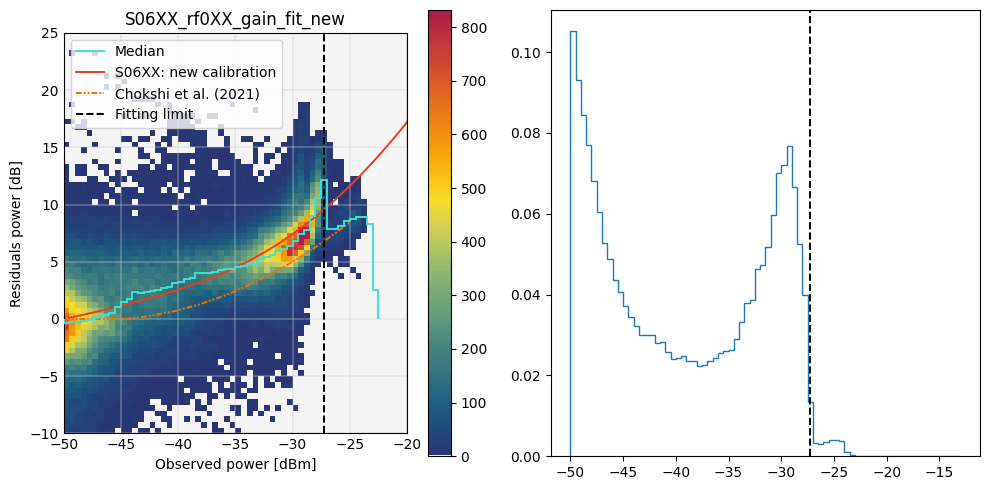

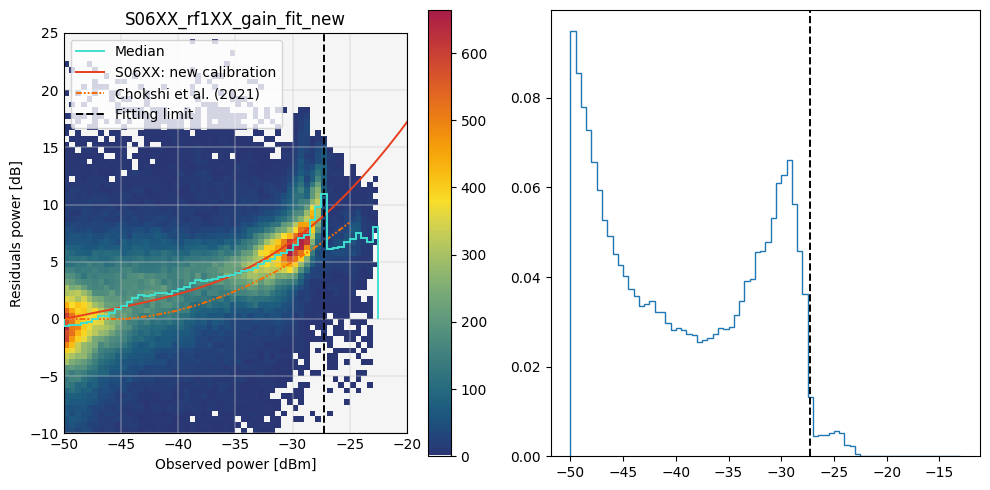

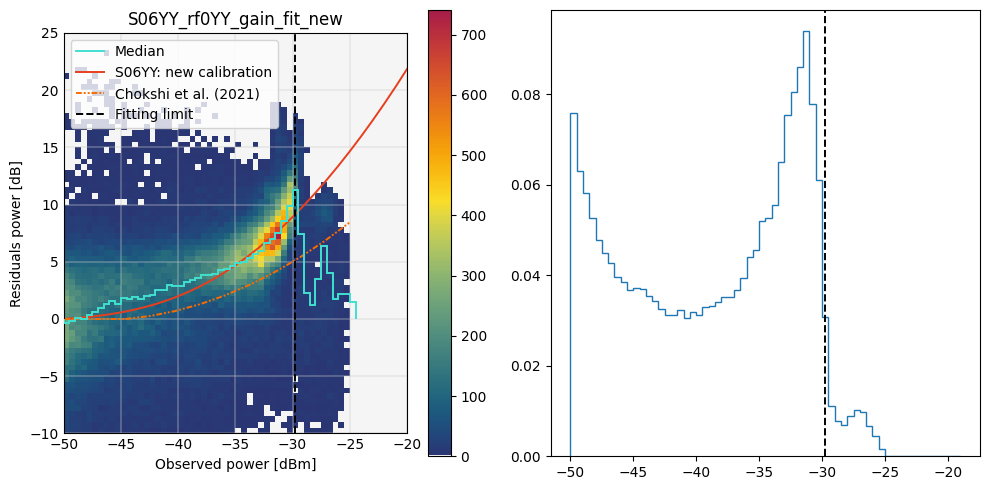

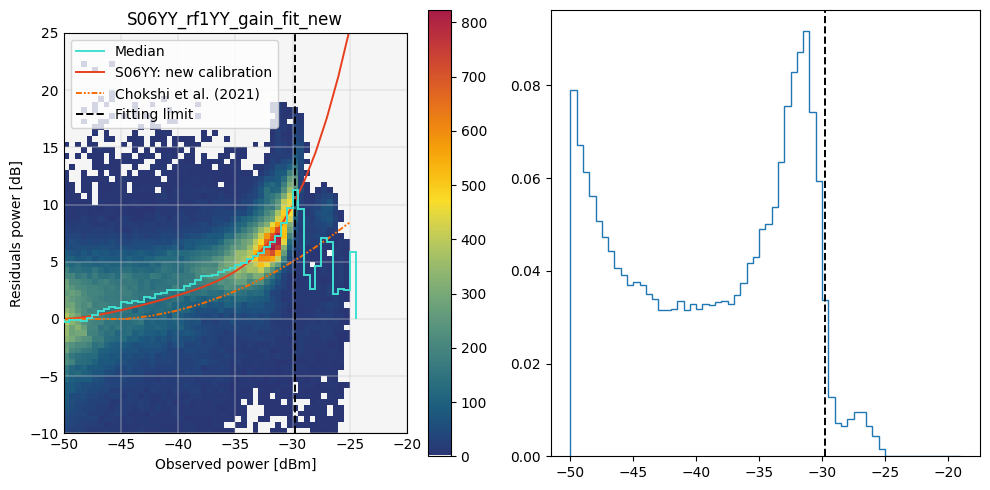

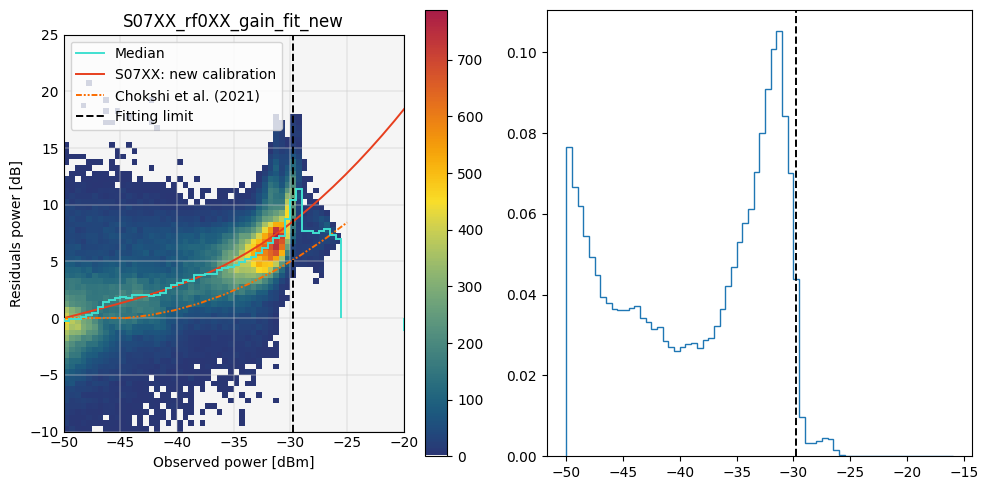

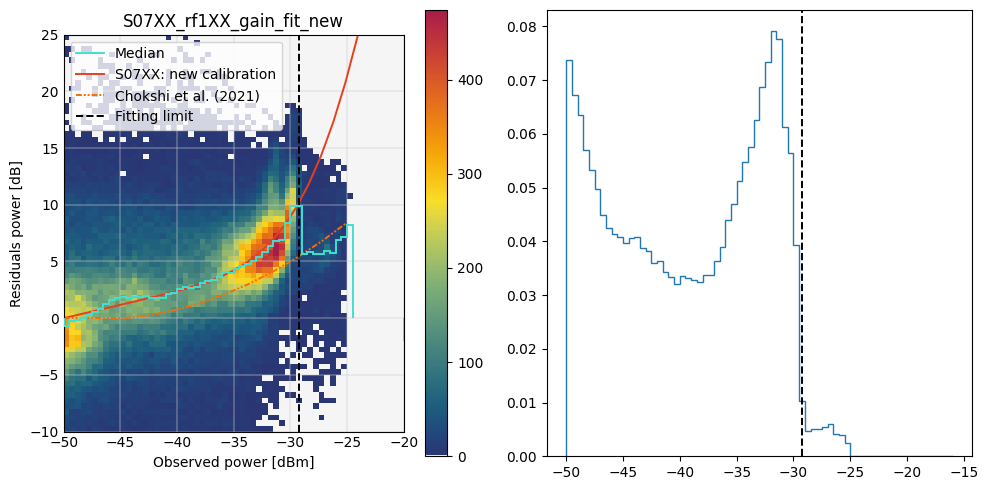

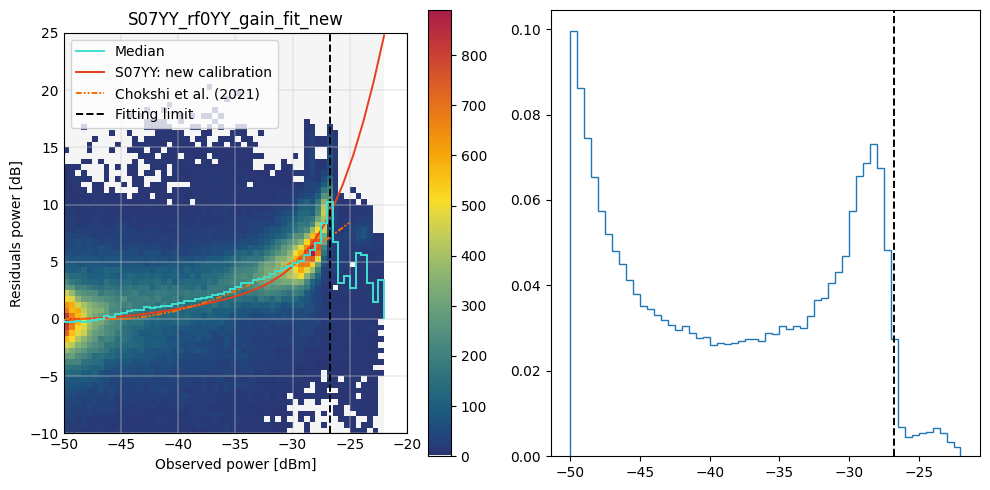

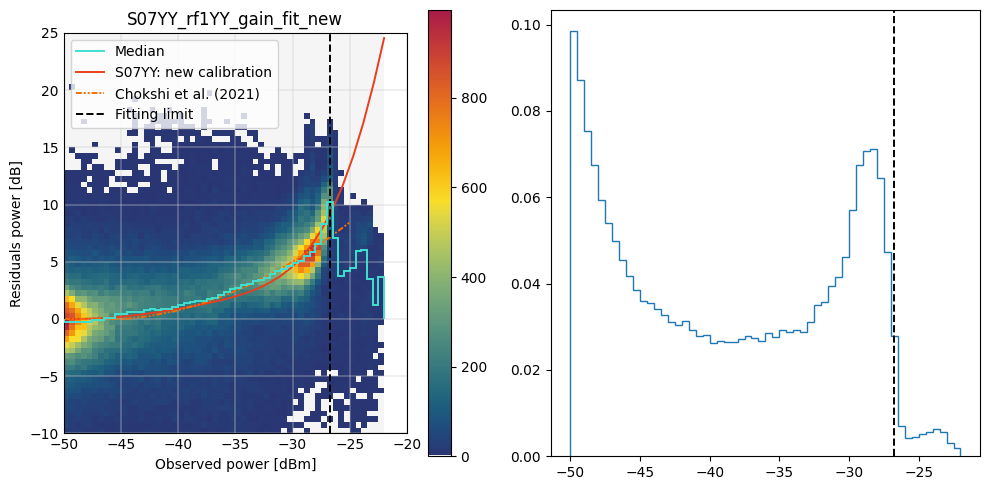

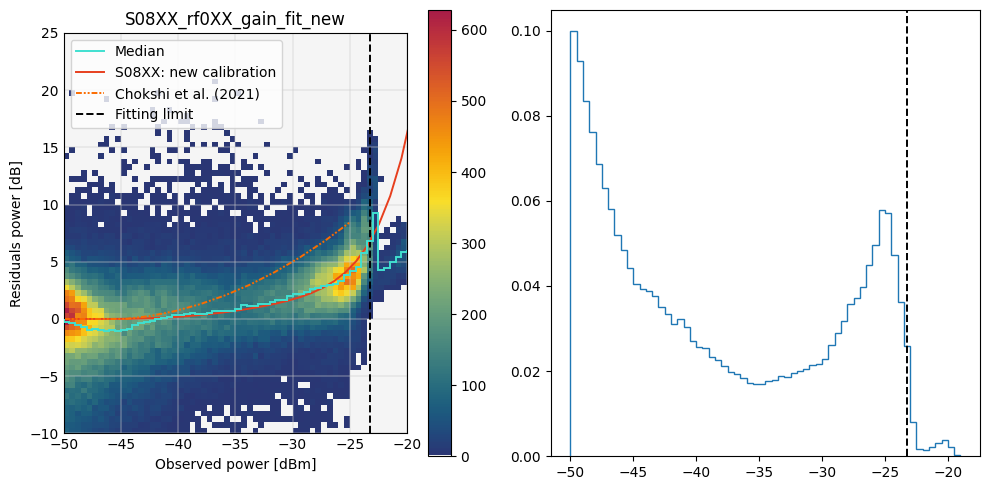

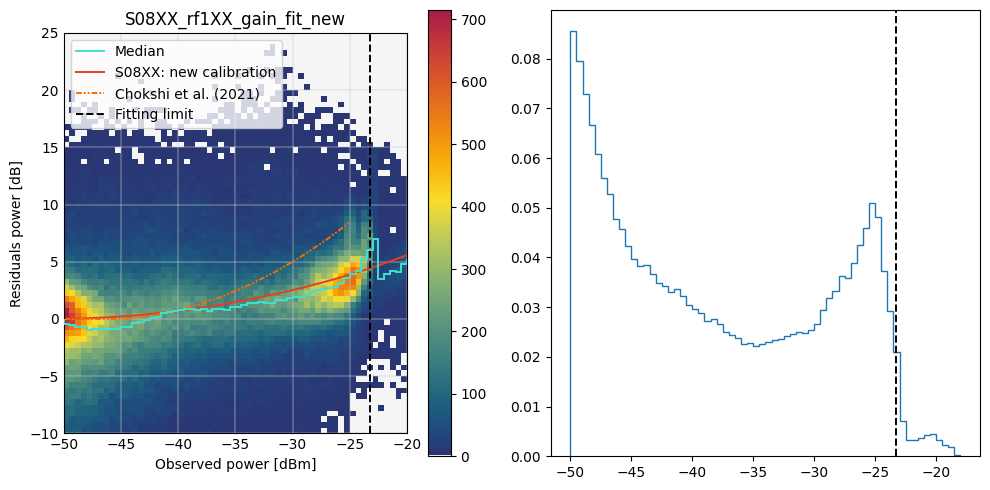

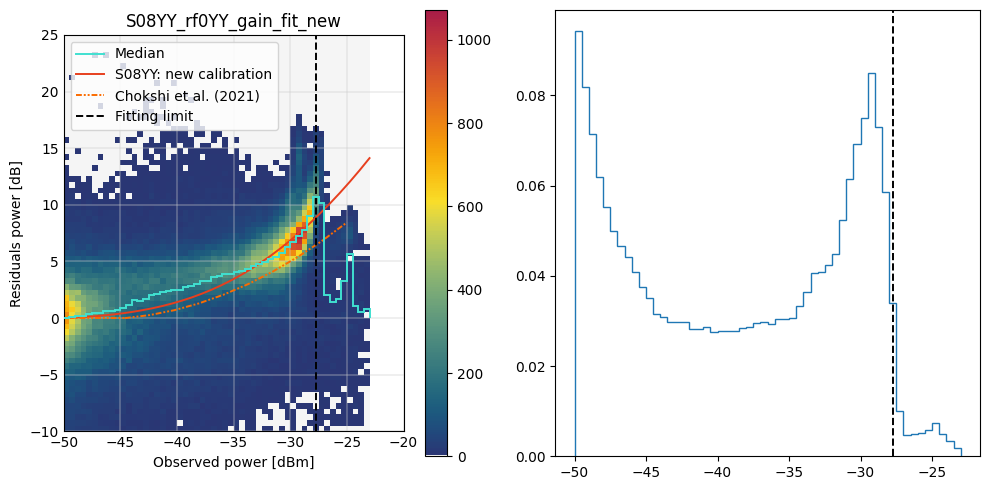

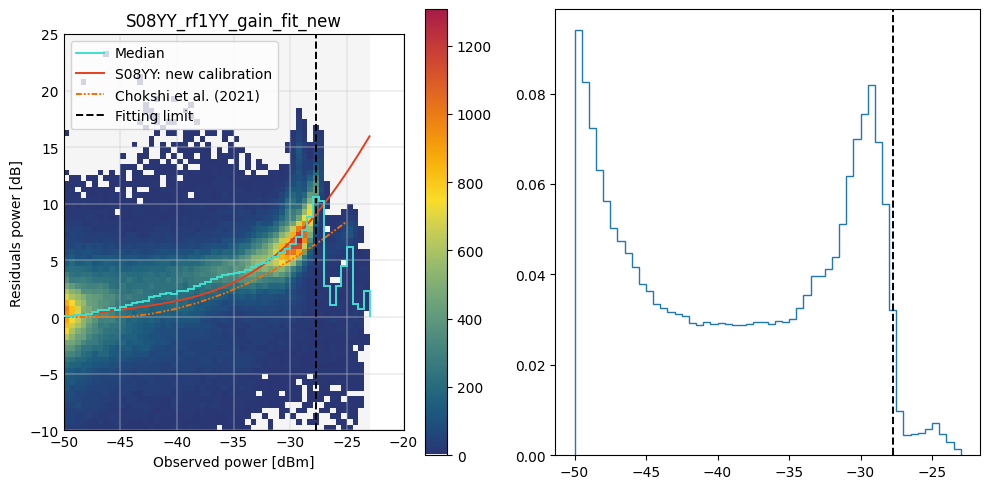

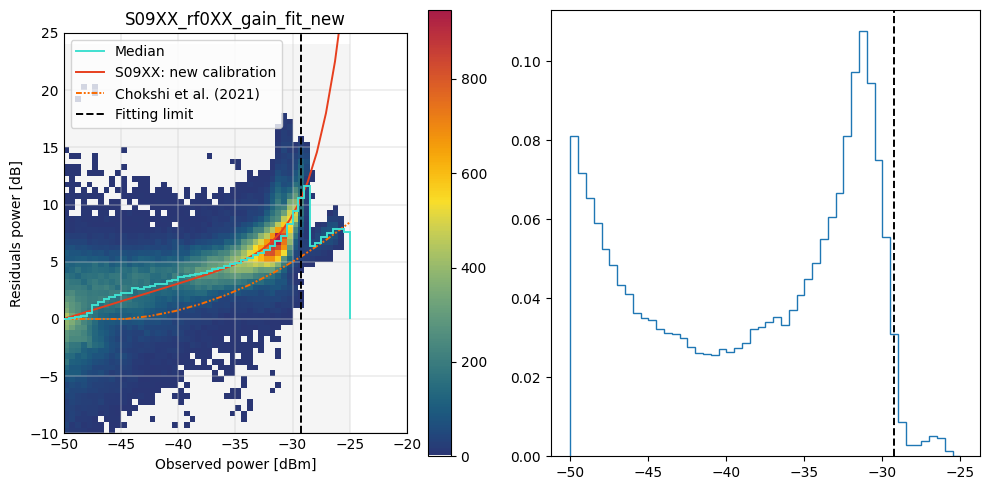

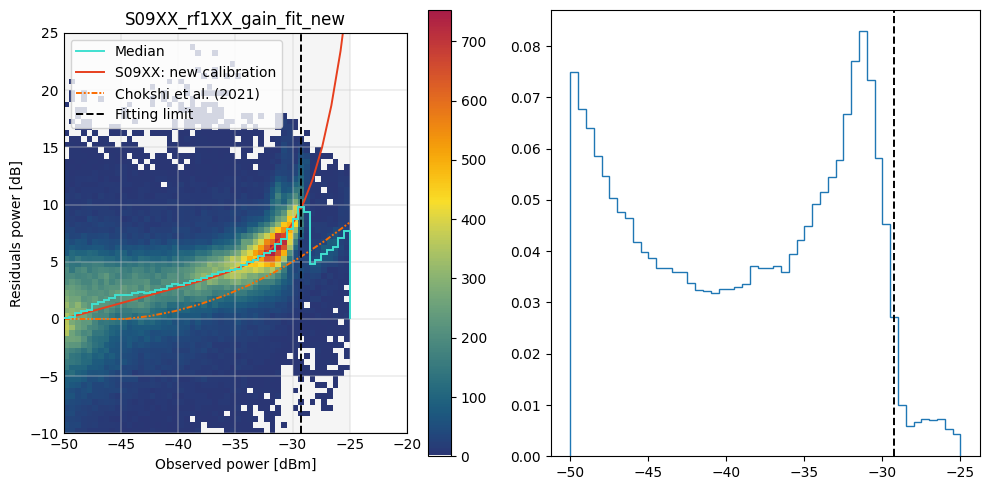

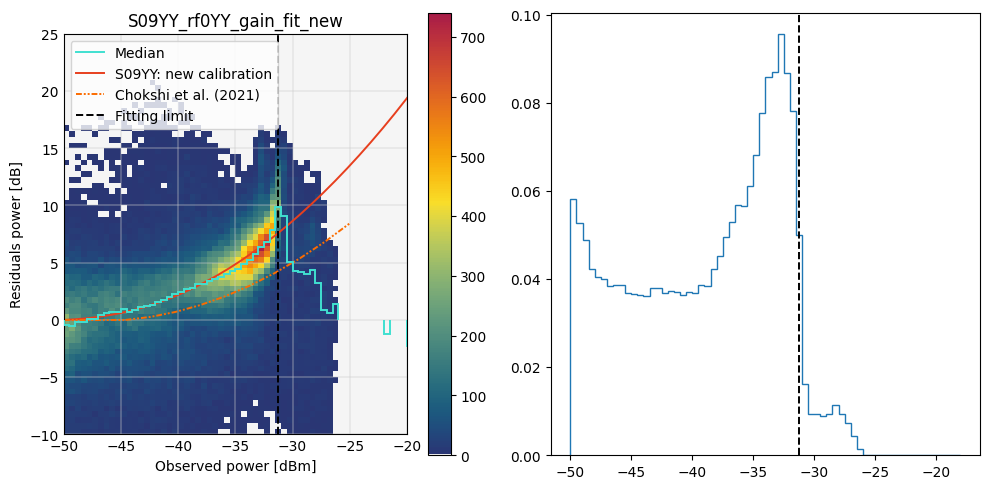

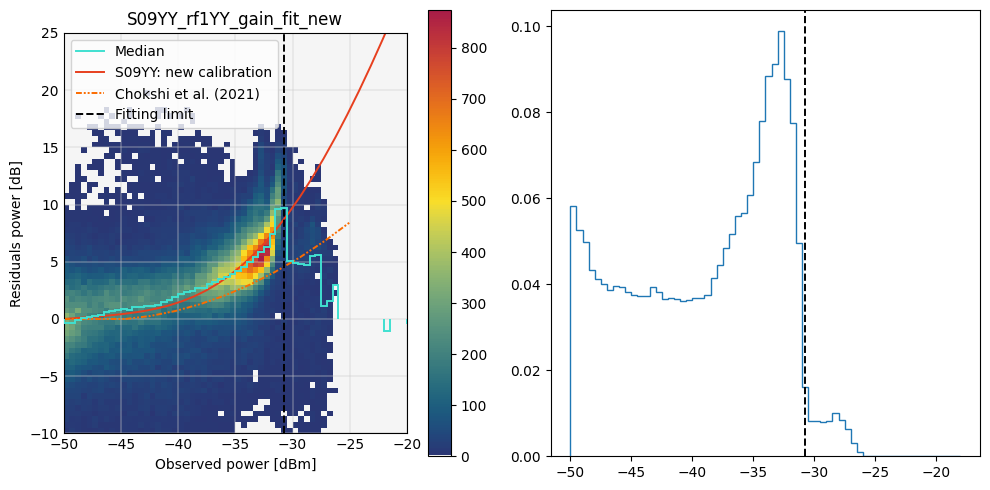

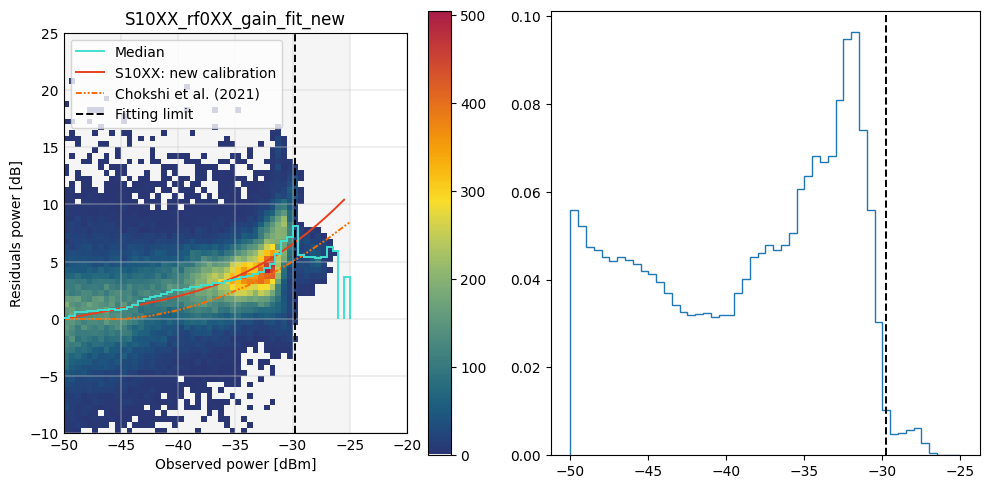

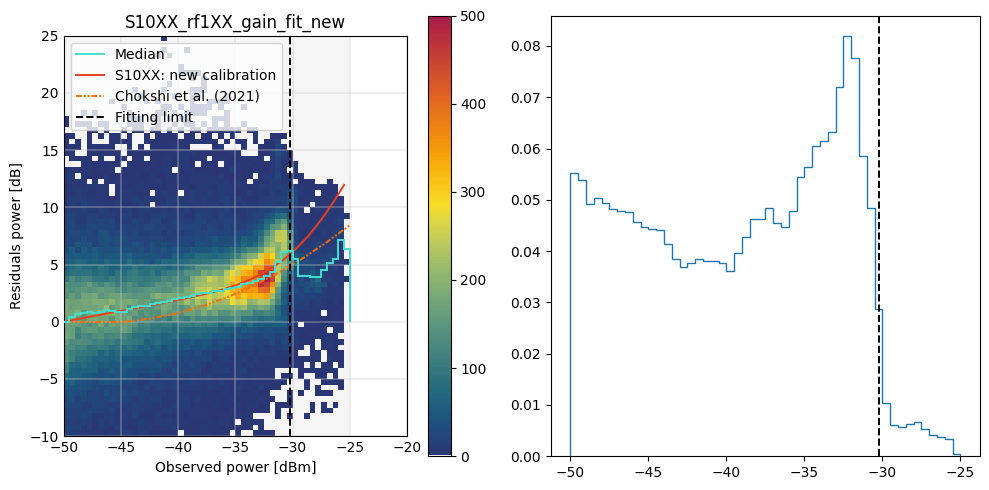

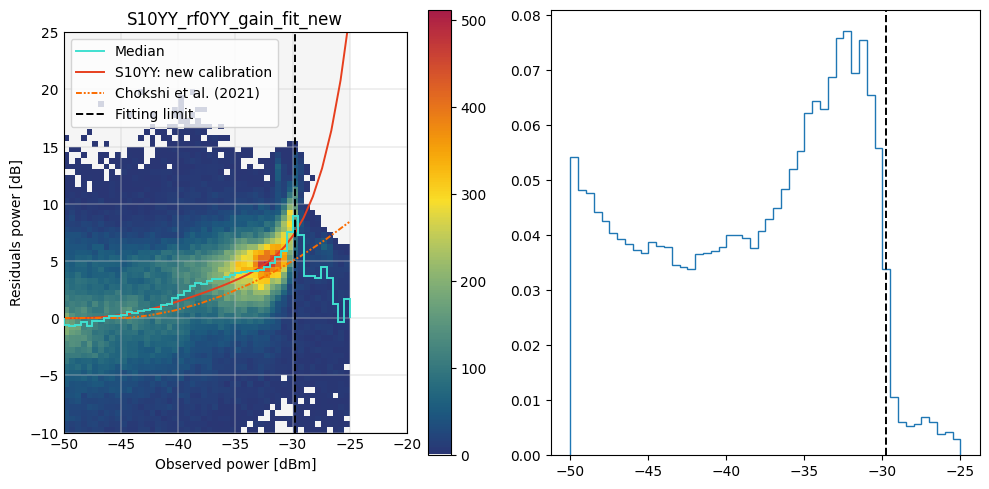

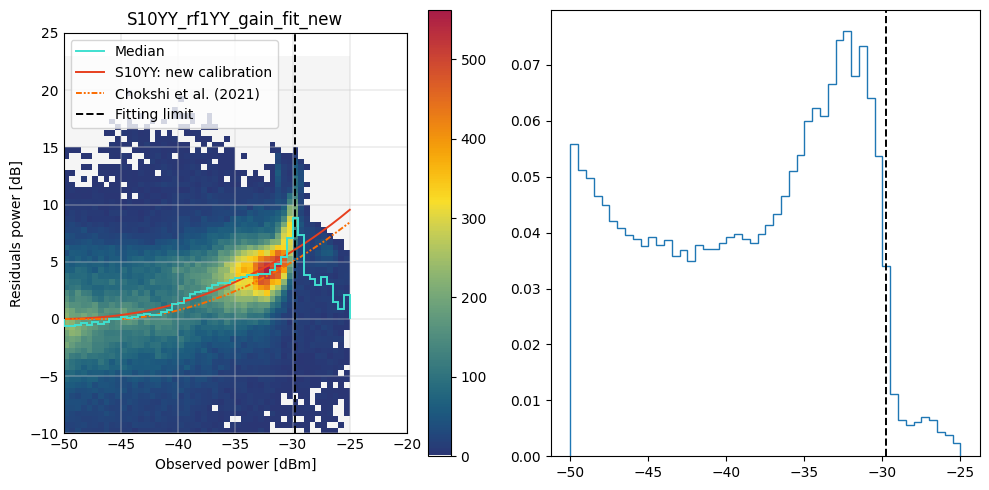

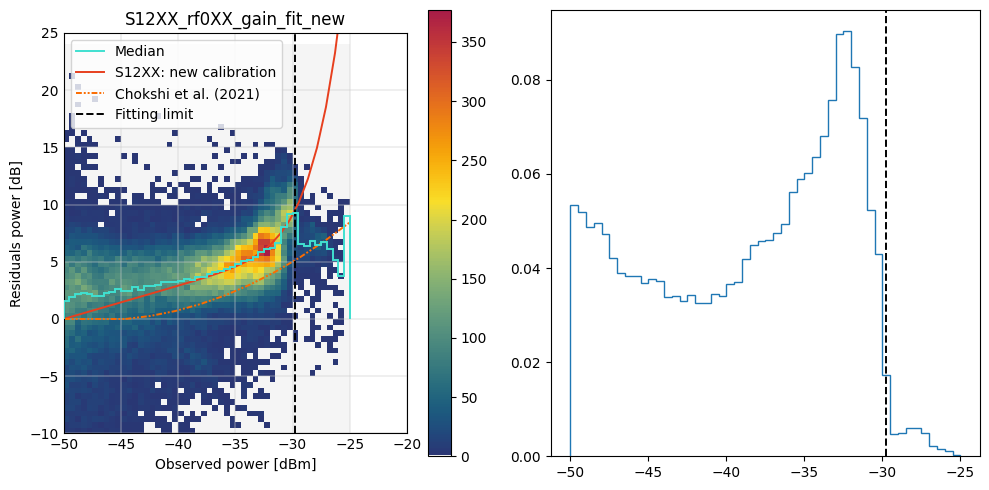

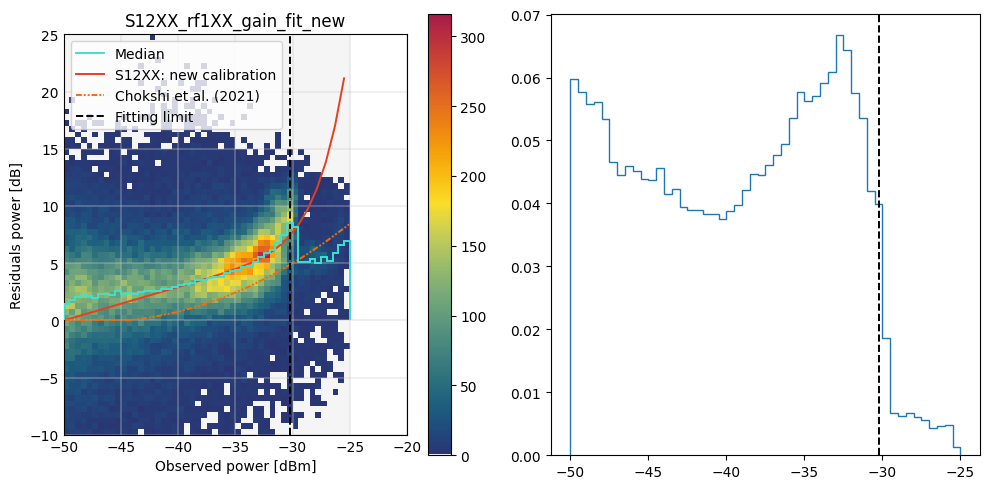

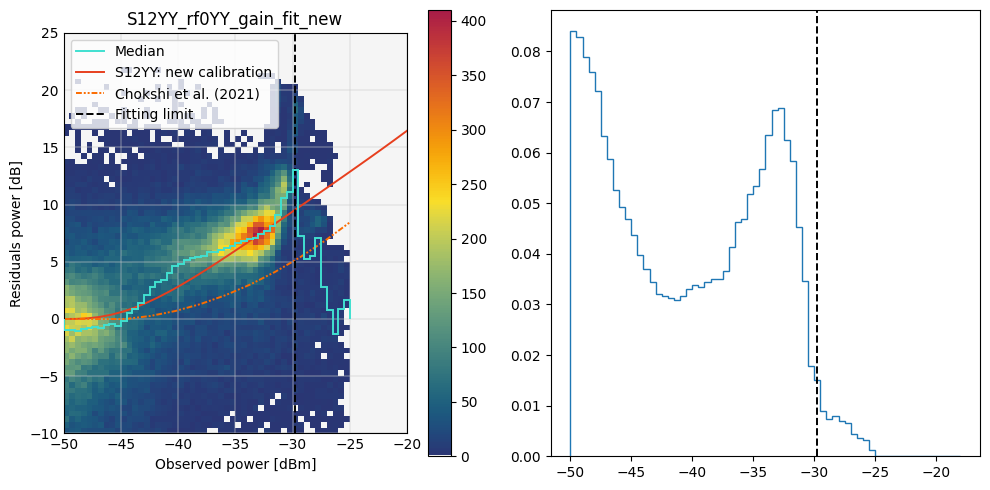

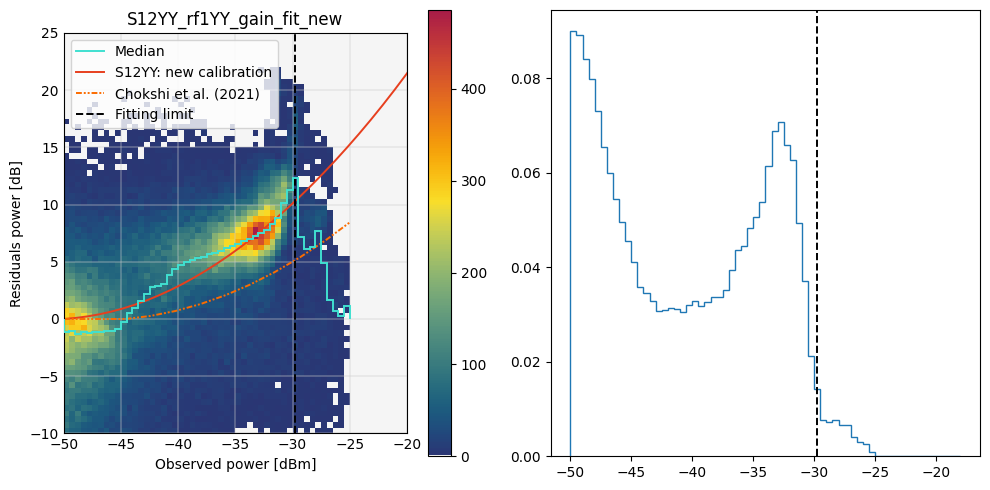

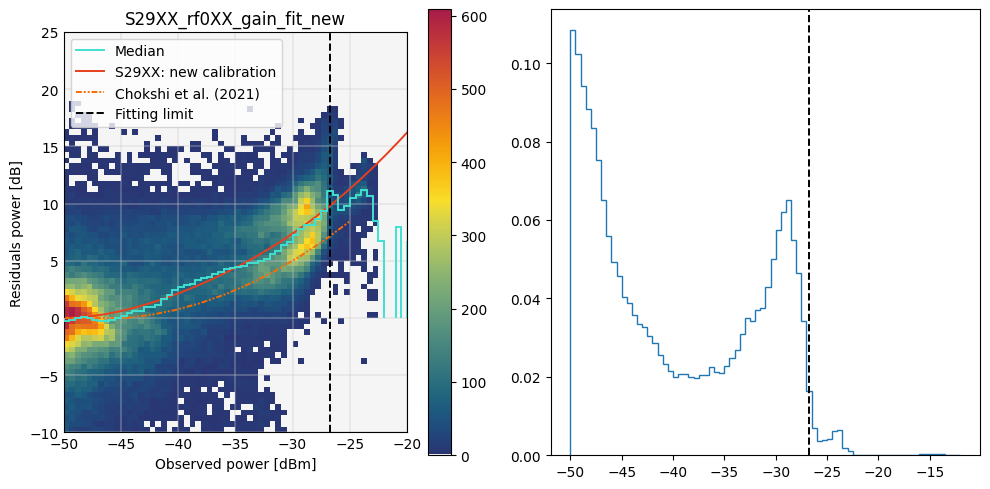

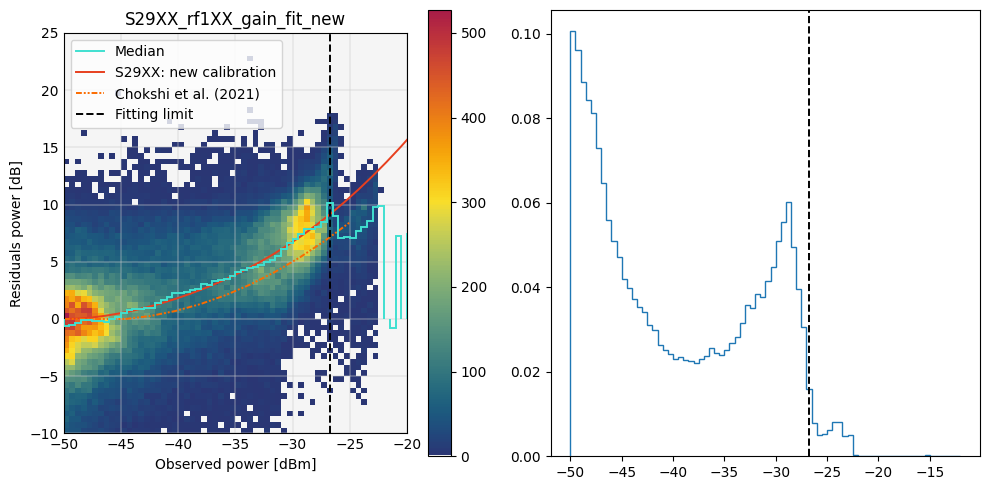

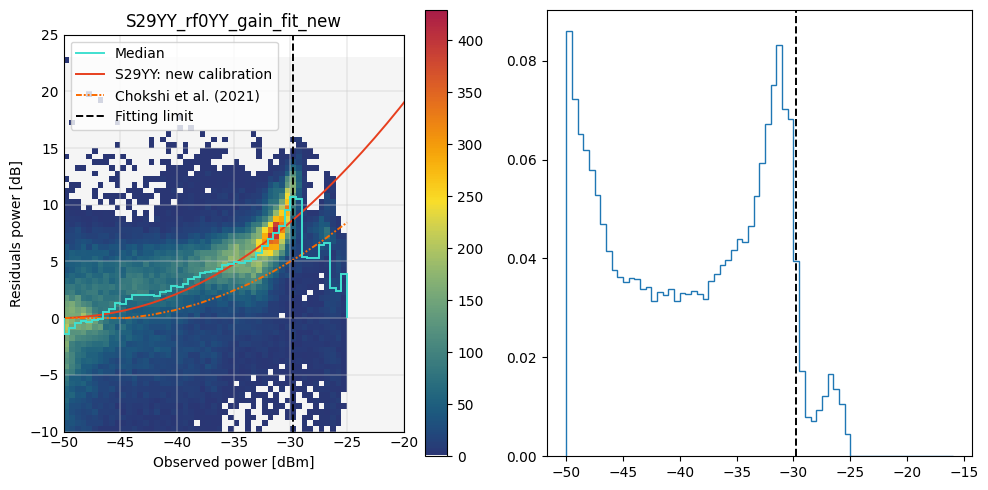

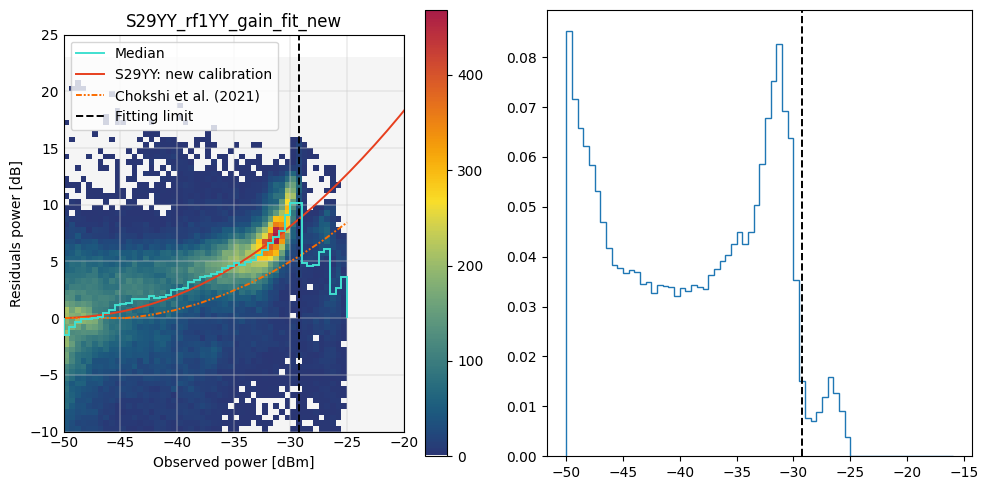

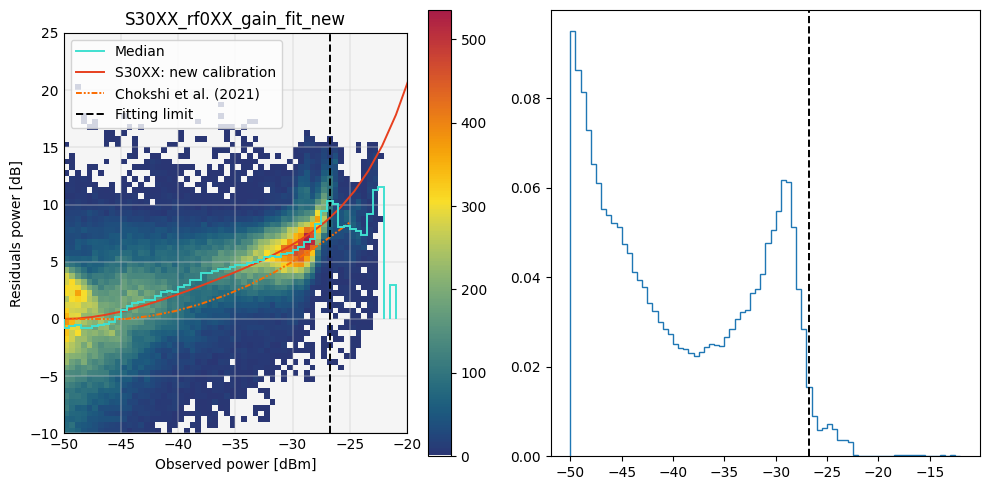

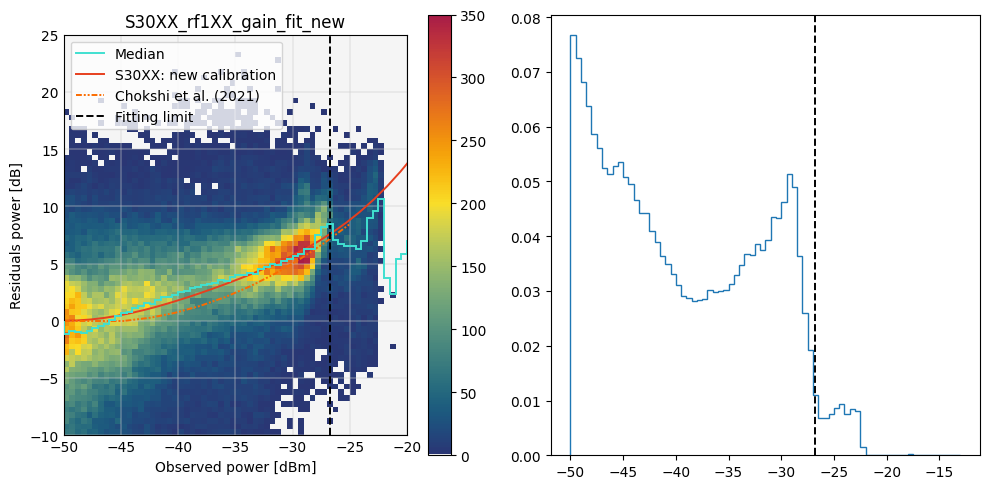

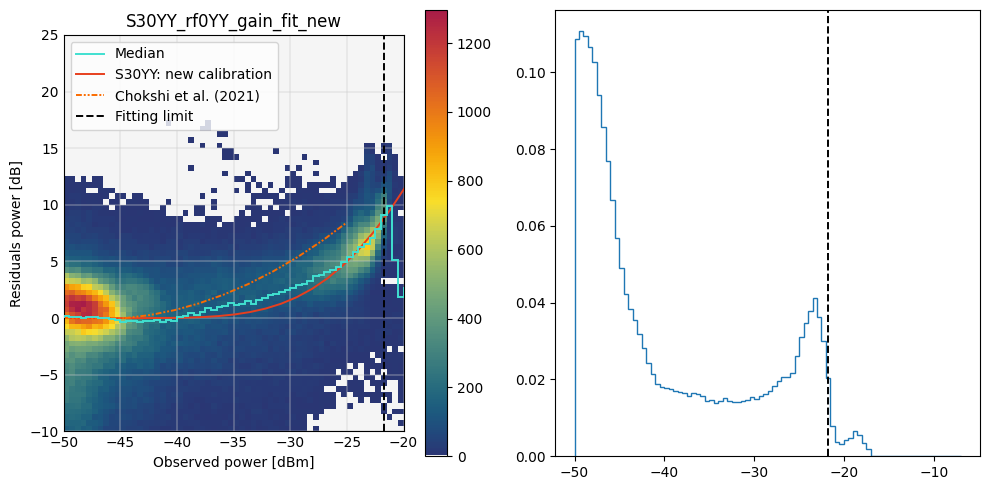

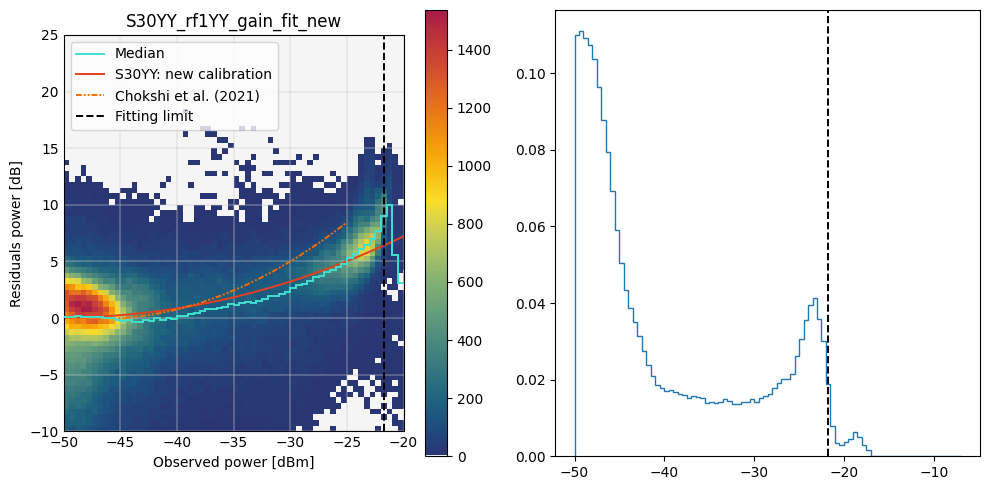

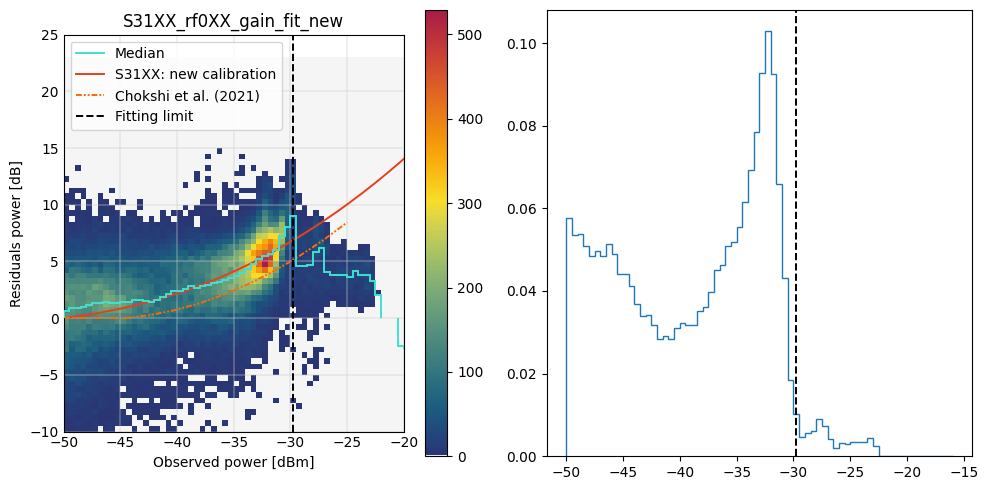

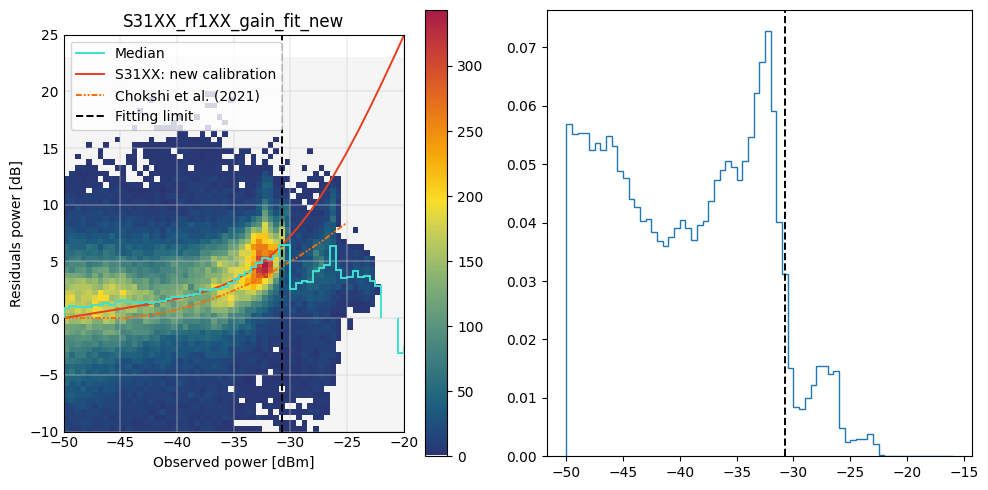

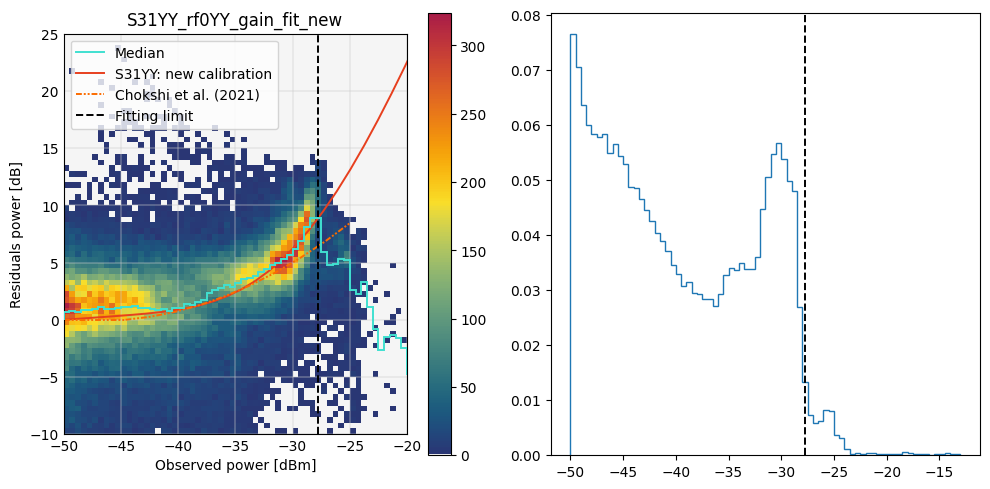

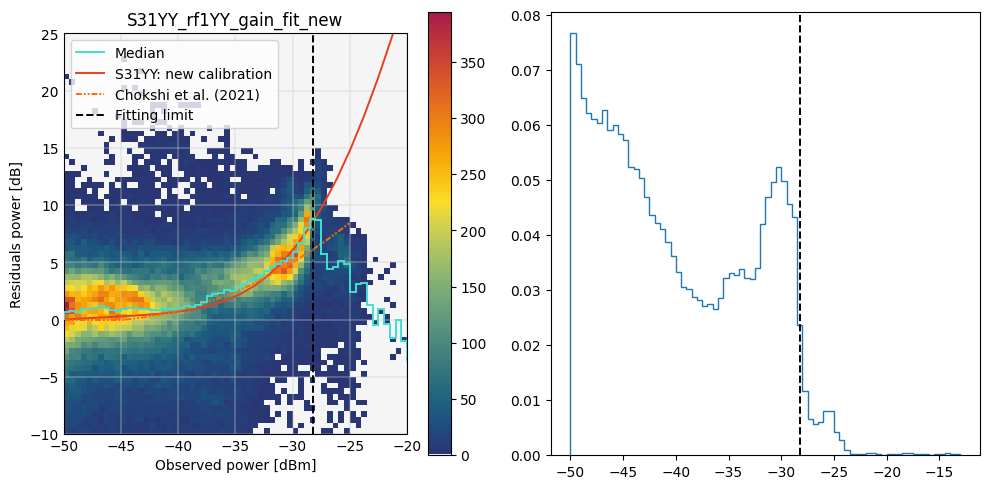

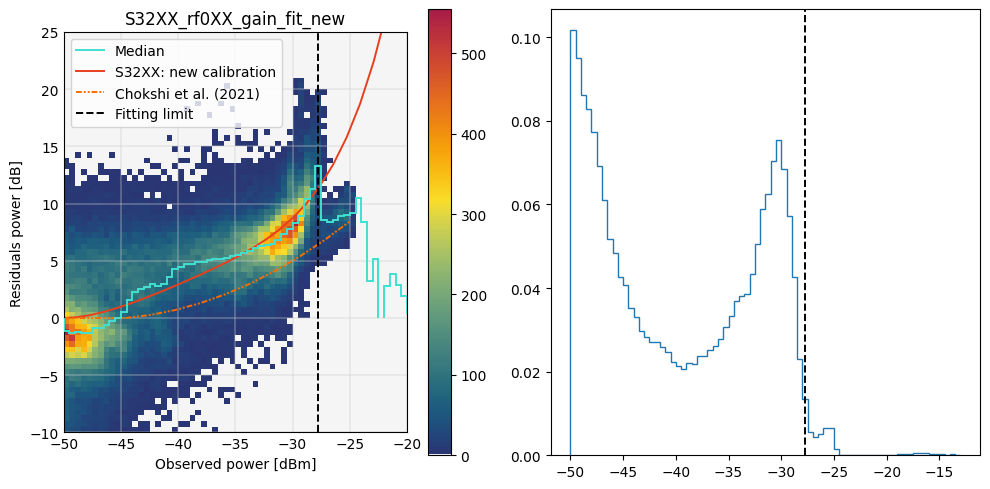

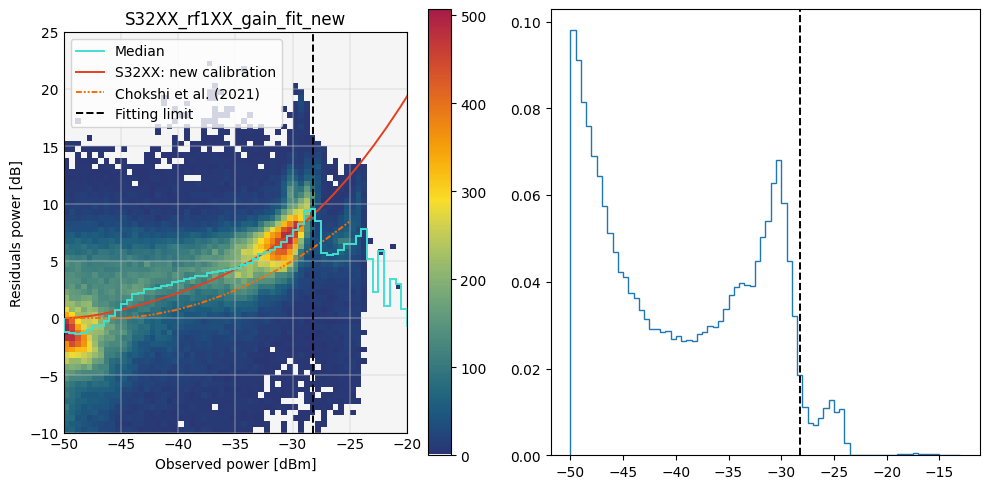

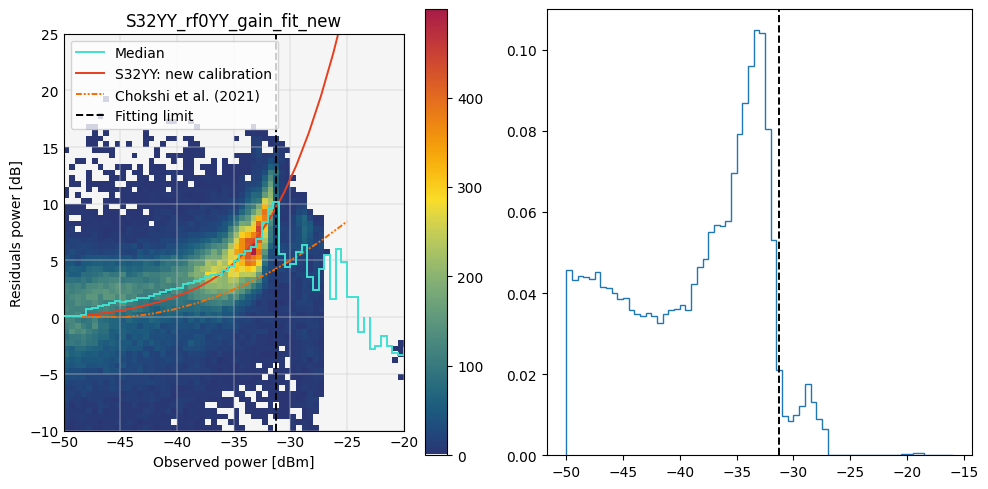

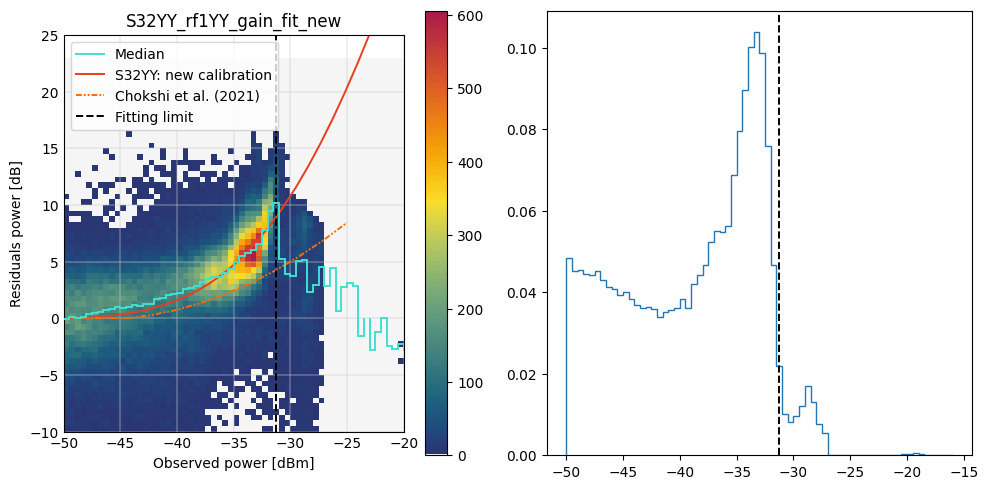

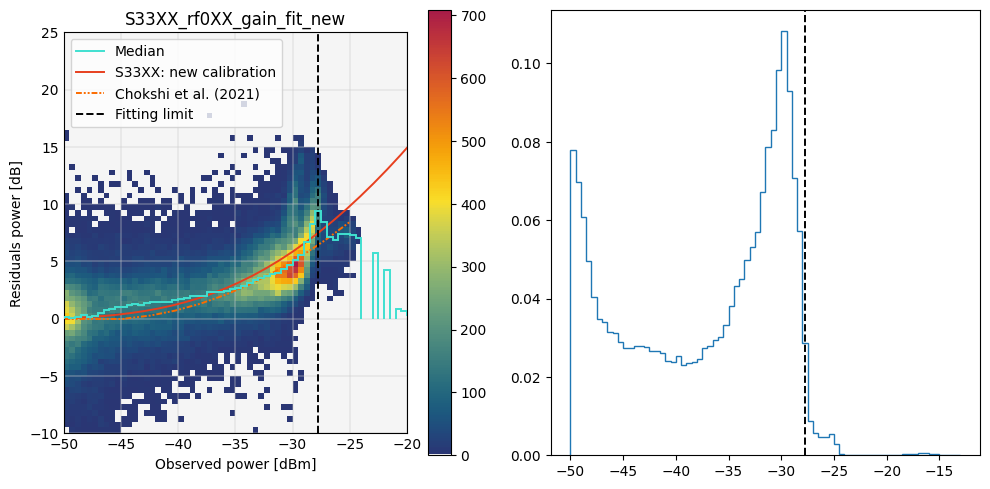

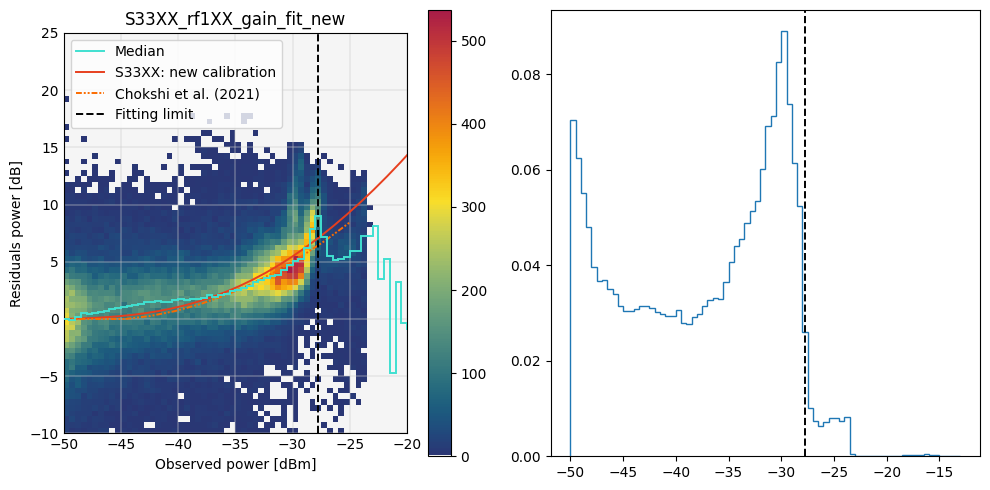

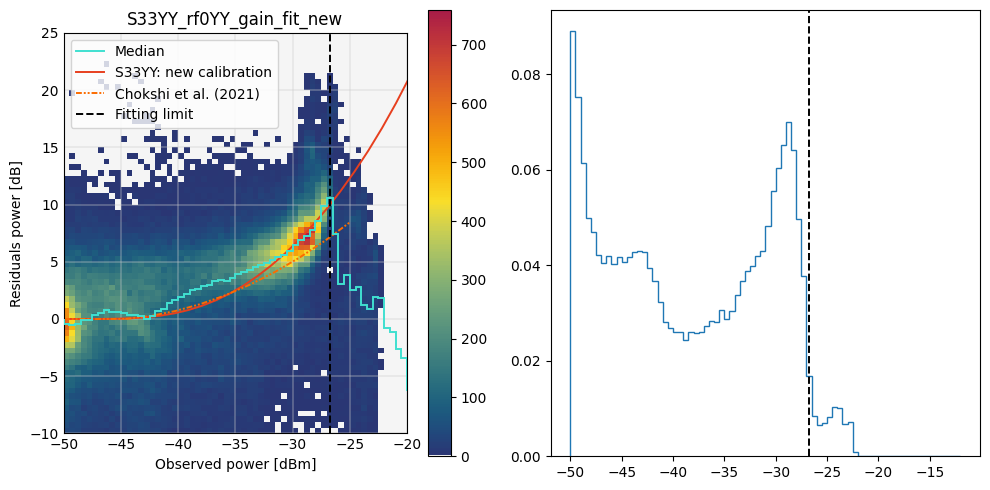

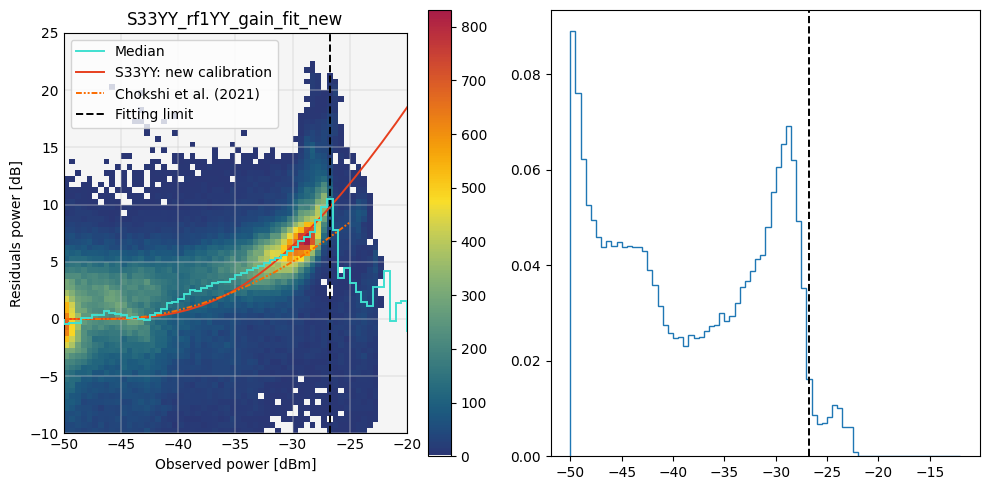

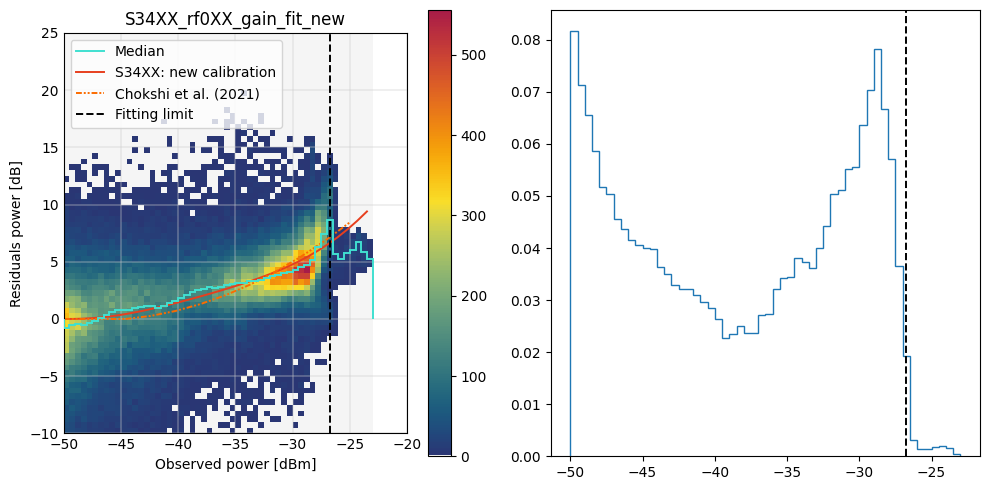

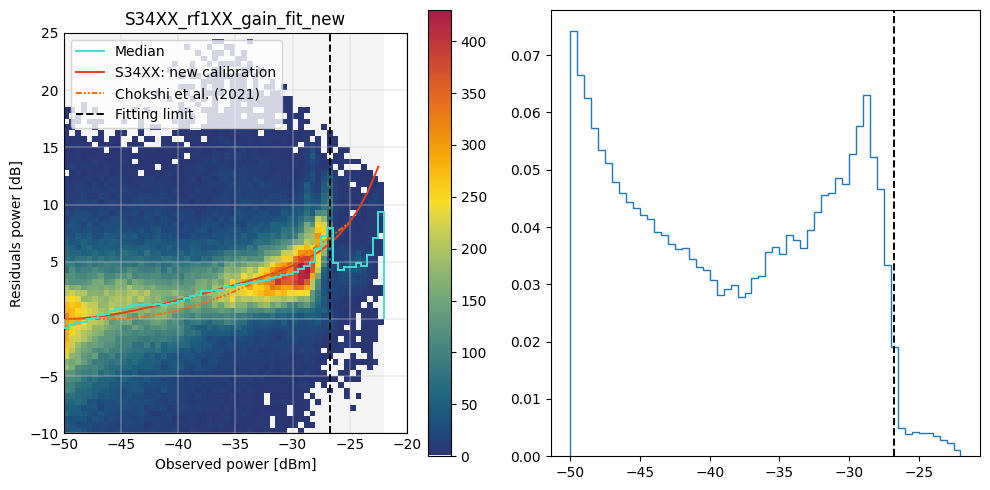

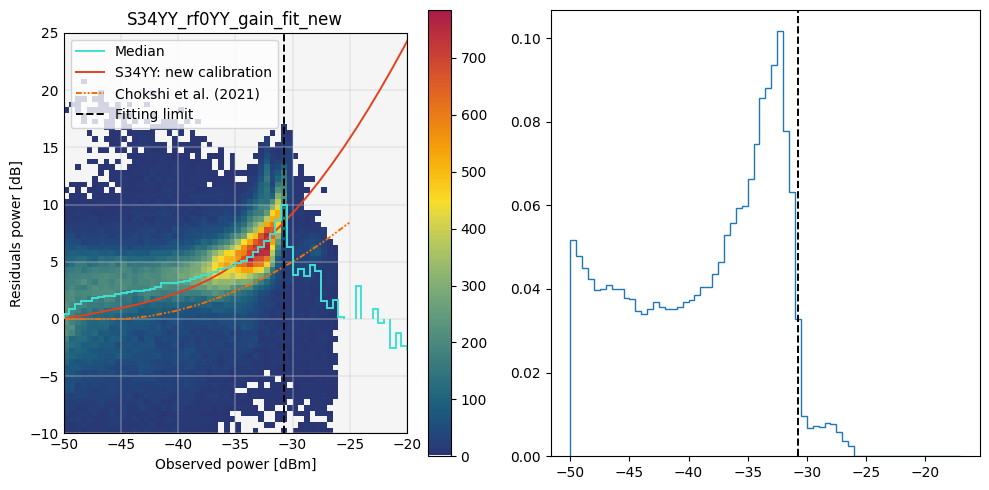

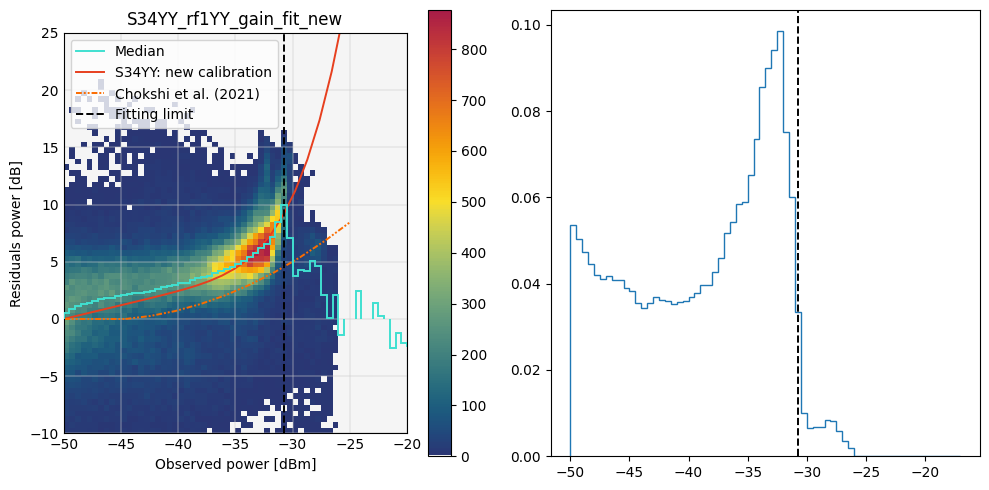

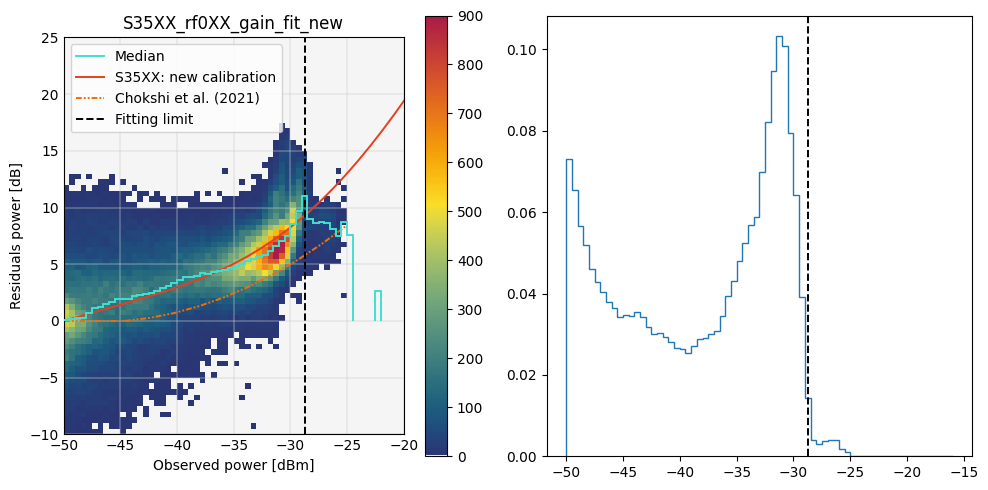

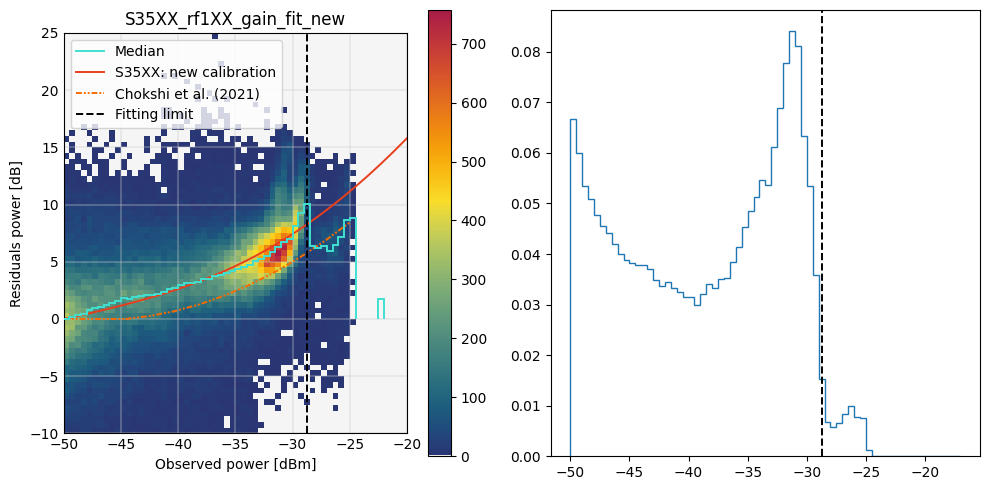

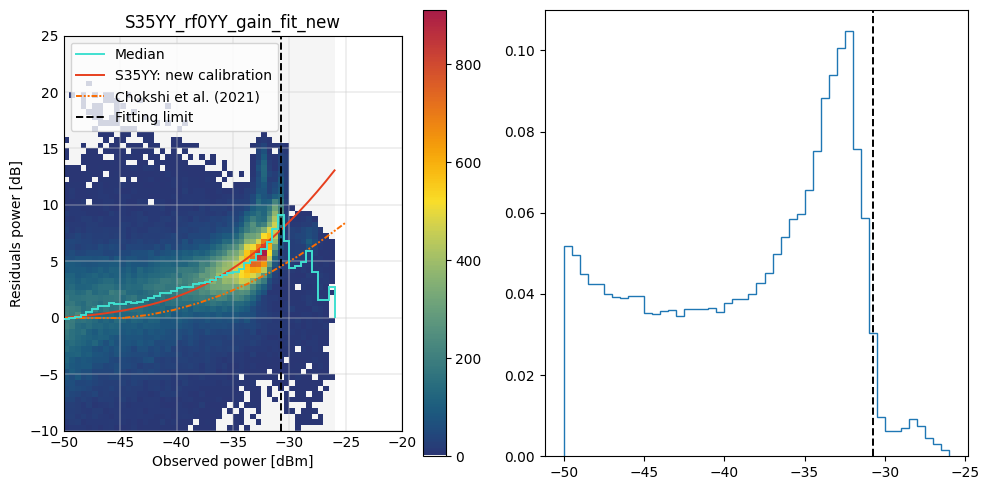

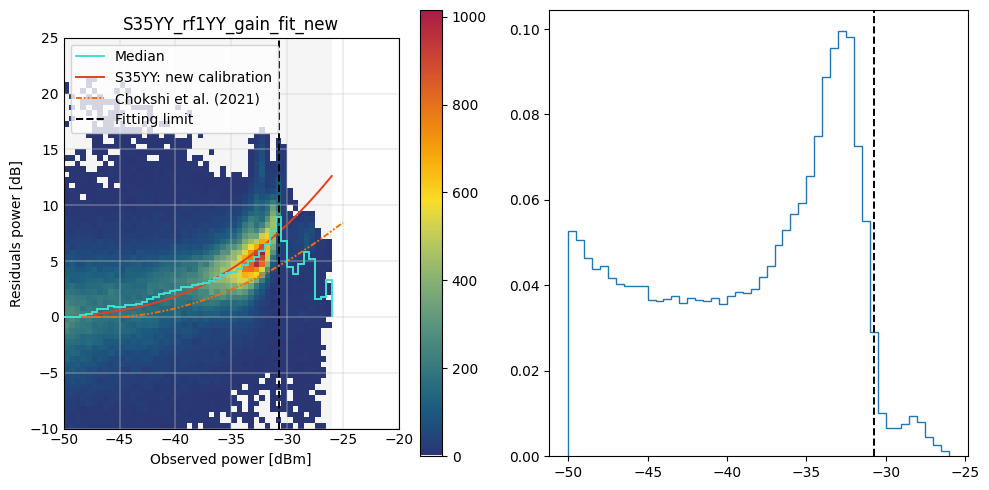

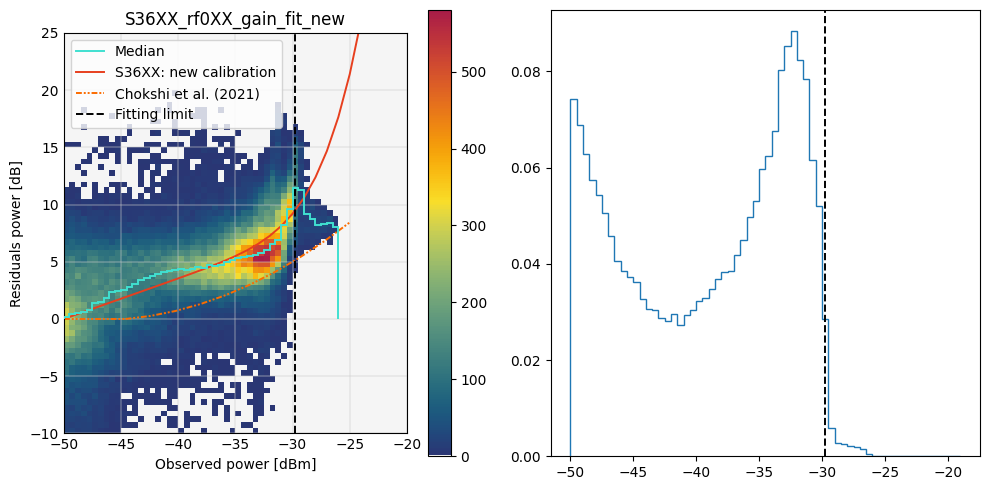

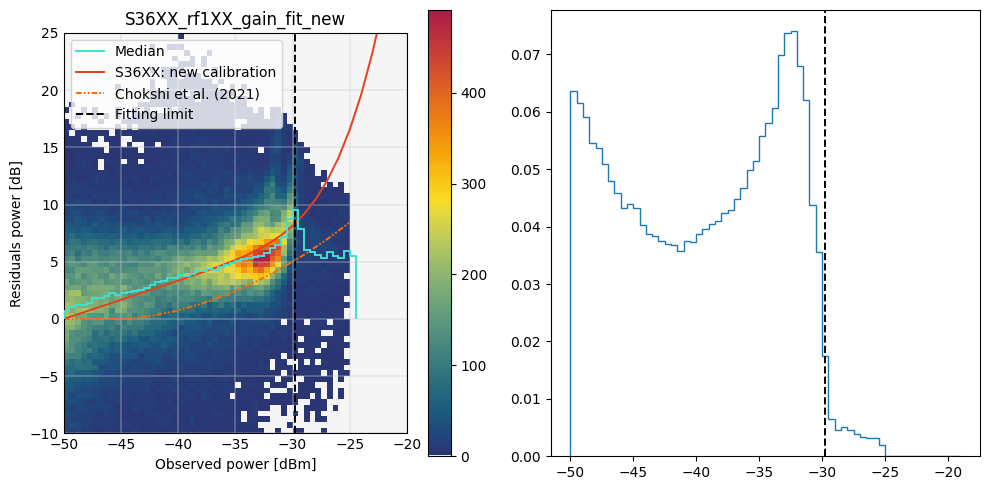

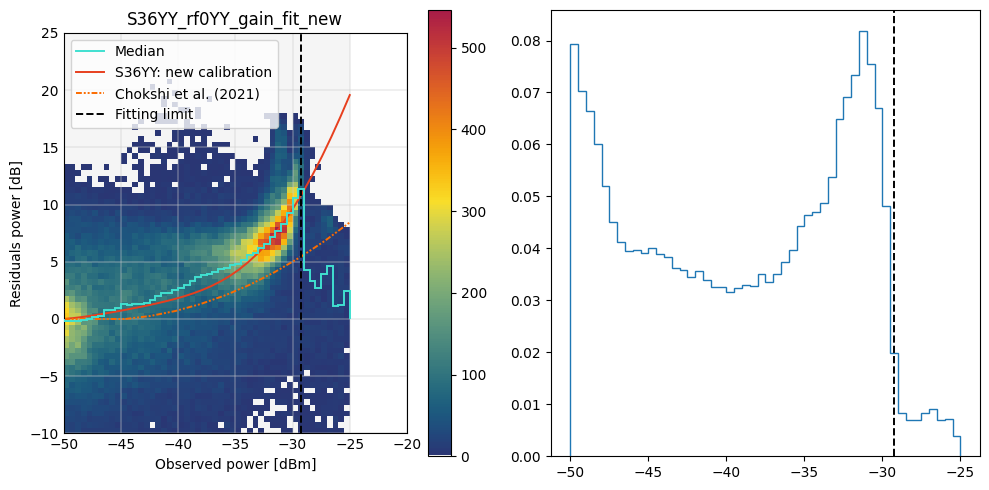

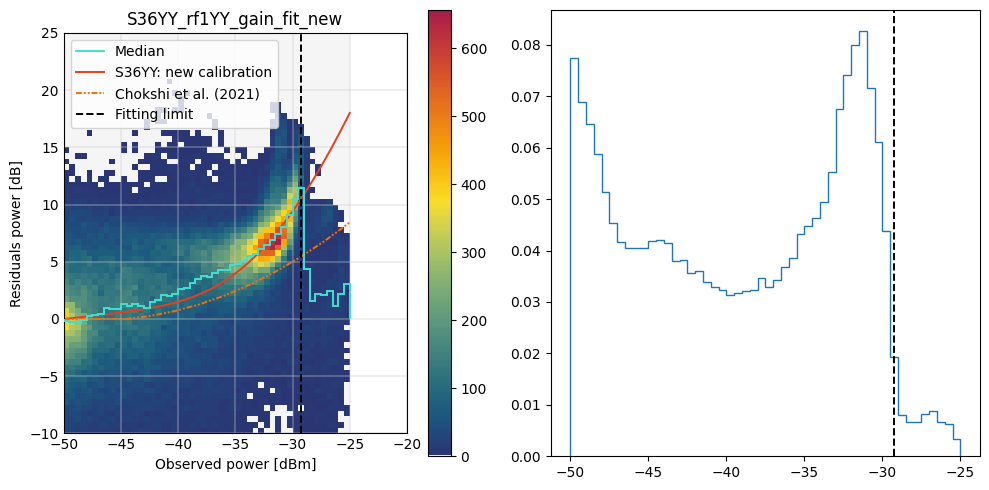

In [11]:
## Chokshi 2021 RFE Cal fit
rfe_polyfit_old = np.load("../passes/rfe_cal/original/rfe_gain_fit.npy")
gain_cal_old = np.poly1d(rfe_polyfit_old)
f = np.poly1d(poly)
x_f = np.linspace(max(f.roots), -25, num=10)
y_f = f(x_f)

rfe_cali_dir = Path("../passes/rfe_cal/rfe_calibration_5hz")
gain_files = sorted(rfe_cali_dir.glob("*gain_fit_new.json"))

data_xlims = (-50, -20)
data_ylims = (-20, 15)

for f in (gain_files):

    with open(f, "r") as data:
        rfe = json.load(data)
        pass_data = np.array(rfe["tile_pass_data"])
        pass_resi = np.array(rfe["pass_resi"])

        # Basic mask
        mask_crop = (
            (pass_data >= data_xlims[0])
            & (pass_resi >= data_ylims[0])
        )

        # Data to be fit
        x_data = pass_data[mask_crop]
        y_data = pass_resi[mask_crop]

        bw = 0.5
        x_data_be = np.arange(data_xlims[0], np.ceil(x_data.max())+bw, +bw)
        y_data_be = np.arange(data_ylims[0], np.ceil(y_data.max())+bw, +bw)

        # Scale to [0, 1] domain
        u_fit = scale_to_unit(x_data, data_xlims[0], x_data.max())

        # Basic Params
        Nc = 10
        highval = 20
        x0 = np.zeros(Nc)
        x0[-1] = 0.2

        x_data_median, _, _ = binned_statistic(x_data, y_data, statistic="median", bins=x_data_be)
        x_data_bc = 0.5 * (x_data_be[:-1] + x_data_be[1:])
        
        # Histogram the data to determine automatic theshold to fit data to
        x_data_hist_norm, _ = np.histogram(x_data, bins=x_data_be, density=True)
        
        # First place density is sufficiently low
        # bc_cut = np.where(np.logical_and(x_data_hist_norm < 0.02, x_data_bc > -30))[0][0]
        # bc_cut = np.nanargmax(x_data_median)
        mask = x_data_hist_norm >= 0.01
        bc_cut = np.where(mask)[0][np.argmax(x_data_median[mask])]

        # # FIT BASED ON MEDIAN
        # Imatr = get_Imatr(scale_to_unit(x_data_bc[:bc_cut], data_xlims[0], x_data.max()), Nc=Nc)
        # y_fit = x_data_median[:bc_cut]

        # FIT BASED ON DATA
        mask_fit = (x_data <= x_data_bc[bc_cut])
        Imatr = get_Imatr(scale_to_unit(x_data[mask_fit], data_xlims[0], x_data.max()), Nc=Nc)
        y_fit = y_data[mask_fit]
        
        soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
        deriv_coeffs_best = np.cumsum(soln["x"])

        u_grid=np.linspace(0, 1, 32)
        Imatr_grid = get_Imatr(u_grid, Nc=Nc)
        y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best


        fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
        
        h = ax[0].hist2d(
            x_data,
            y_data,
            bins=[x_data_be, y_data_be],
            cmap=prd,
        )

        ax[0].stairs(
            x_data_median,
            x_data_be,
            color="turquoise",
            lw=1.4,
            label=f"Median",
            zorder=7,
            # alpha=0.7,
        )

        fig.colorbar(h[3])

        ax[0].plot(scale_from_unit(u_grid, data_xlims[0], x_data.max()), y_grid, label=f"{f.stem[:5]}: new calibration", color="#E73F1E", lw=1.4)

        ax[0].plot(x_f, y_f, label="Chokshi et al. (2021)", color="#FB6C00", lw=1.4, ls=(0, (3, 1, 1, 1, 1, 1)))
        ax[0].plot([-50, x_f[0]], [0, 0], color="#FB6C00", lw=1.4, ls=(0, (3, 1, 1, 1, 1, 1)))
        
        ax[0].axvline(x_data_bc[bc_cut], color="k", linestyle="--", lw=1.4, label="Fitting limit",)

        ax[1].hist(x_data, bins=x_data_be, histtype="step", density=True)
        ax[1].axvline(x_data_bc[bc_cut], color="k", linestyle="--", lw=1.4, label="Fitting limit",)
        
        ax[0].set_xlabel("Observed power [dBm]")
        ax[0].set_ylabel("Residuals power [dB]")
        ax[0].tick_params(axis="both", length=0)
        ax[0].grid(color="#cccccc", alpha=0.36, lw=1.2)
        ax[0].set_aspect("equal")
        ax[0].set_title(f.stem)

        ax[0].legend(loc="upper left")

        ax[0].set_xlim(data_xlims)
        ax[0].set_ylim(-10, 25)
        
        plt.tight_layout()
        plt.show()
        
        fit_key = f"{f.stem[:11]}"
        
        save_rfe_fit(
            output_file=rfe_cali_dir / "rfe_compression_monotonic_concave_fits.json",
            fit_key=fit_key,
            fit_min=data_xlims[0],
            fit_max=x_data.max(),
            data_cutoff=bc_cut,
            degree=Nc,
            derivative_coefficients=deriv_coeffs_best,
            optimizer_increments=soln.x,
        )

        # break

In [ ]:
def load_rfe_fit(
    fit_file: str | Path,
    fit_key: str,
) -> dict:
    """Load one tile/reference compression fit."""
    with Path(fit_file).open("r") as stream:
        payload = json.load(stream)

    try:
        return payload["fits"][fit_key]
    except KeyError as exc:
        available = ", ".join(sorted(payload.get("fits", {})))
        raise KeyError(
            f"No fit named {fit_key!r}. Available fits: {available}"
        ) from exc

In [ ]:
def evaluate_rfe_residual(
    observed_power: np.ndarray,
    fit: dict,
    *,
    below_fit: str = "zero",
    above_fit: str = "clip",
) -> np.ndarray:
    """
    Evaluate the missing-power correction for observed RF Explorer power.

    Parameters
    ----------
    observed_power
        Measured tile power in dBm.
    fit
        Record returned by `load_rfe_fit`.
    below_fit
        Behaviour below `fit_min_dbm`:

        - ``"zero"``: return zero correction;
        - ``"extrapolate"``: evaluate outside the fitted domain.

    above_fit
        Behaviour above `fit_max_dbm`:

        - ``"clip"``: use the correction at the upper boundary;
        - ``"extrapolate"``: evaluate outside the fitted domain;
        - ``"nan"``: return NaN.

    Returns
    -------
    ndarray
        Additive correction in dB.
    """
    power = np.asarray(observed_power, dtype=float)

    fit_min = float(fit["fit_min_dbm"])
    fit_max = float(fit["fit_max_dbm"])
    degree = int(fit["degree"])

    coeffs = np.asarray(
        fit["derivative_coefficients"],
        dtype=float,
    )

    if coeffs.size != degree:
        raise ValueError(
            f"Expected {degree} coefficients, found {coeffs.size}."
        )

    u = scale_to_unit(power, fit_min, fit_max)
    u_eval = u.copy()

    if above_fit == "clip":
        u_eval = np.minimum(u_eval, 1.0)
    elif above_fit == "nan":
        pass
    elif above_fit != "extrapolate":
        raise ValueError(f"Unknown above_fit option: {above_fit!r}")

    if below_fit == "zero":
        u_eval = np.maximum(u_eval, 0.0)
    elif below_fit != "extrapolate":
        raise ValueError(f"Unknown below_fit option: {below_fit!r}")

    design = get_Imatr(u_eval, Nc=degree)
    correction = design[:, 1:] @ coeffs

    if below_fit == "zero":
        correction = np.where(power < fit_min, 0.0, correction)

    if above_fit == "nan":
        correction = np.where(power > fit_max, np.nan, correction)

    correction = np.where(np.isfinite(power), correction, np.nan)

    return correction

### Paper Plot

In [12]:
prd_paper = LSC.from_list("pride", cmr.pride(np.linspace(0.2, 0.9, 256)))
prd_paper.set_under("white")

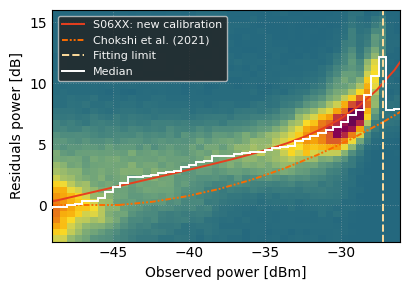

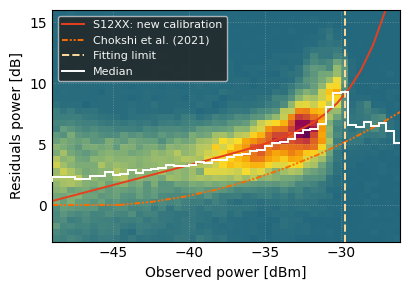

In [14]:
# rfe_cali_dir = Path("../passes/rfe_cal/20260714")
rfe_cali_dir = Path("../passes/rfe_cal/rfe_calibration_5hz")
gain_files = sorted(rfe_cali_dir.glob("*gain_fit_new.json"))

## Chokshi 2021 RFE Cal fit
rfe_polyfit_old = np.load("../passes/rfe_cal/original/rfe_gain_fit.npy")
gain_cal_old = np.poly1d(rfe_polyfit_old)
f = np.poly1d(poly)
x_f = np.linspace(max(f.roots), -25, num=10)
y_f = f(x_f)


data_xlims = (-50, -15)
data_ylims = (-10, 15)

for f in (gain_files):
    if "S06XX_rf0XX" in f.stem or "S12XX_rf0XX" in f.stem:
        with open(f, "r") as data:
            rfe = json.load(data)
            pass_data = np.array(rfe["tile_pass_data"])
            pass_resi = np.array(rfe["pass_resi"])
            pass_hpx = np.array(rfe["hpx_idx"])

            # Basic mask
            mask_crop = (
                (pass_data >= data_xlims[0])
                & (pass_resi >= data_ylims[0])
            )

            # Data to be fit
            x_data = pass_data[mask_crop]
            y_data = pass_resi[mask_crop]

            bw = 0.5
            x_data_be = np.arange(data_xlims[0], np.ceil(x_data.max())+bw, +bw)
            y_data_be = np.arange(data_ylims[0], np.ceil(y_data.max())+bw, +bw)

            # Scale to [0, 1] domain
            u_fit = scale_to_unit(x_data, data_xlims[0], x_data.max())

            # Basic Params
            Nc = 10
            highval = 20
            x0 = np.zeros(Nc)
            x0[-1] = 0.2

            x_data_median, _, _ = binned_statistic(x_data, y_data, statistic="median", bins=x_data_be)
            x_data_bc = 0.5 * (x_data_be[:-1] + x_data_be[1:])
            
            # Histogram the data to determine automatic theshold to fit data to
            x_data_hist_norm, _ = np.histogram(x_data, bins=x_data_be, density=True)
            
            # First place density is sufficiently low
            bc_cut = np.where(np.logical_and(x_data_hist_norm < 0.02, x_data_bc > -32.5))[0][0]
            Imatr = get_Imatr(scale_to_unit(x_data_bc[:bc_cut], data_xlims[0], x_data.max()), Nc=Nc)
            y_fit = x_data_median[:bc_cut]
            soln = minimize(proxy_objective, x0=x0, bounds=Nc * [[0, highval]])
            deriv_coeffs_best = np.cumsum(soln["x"])

            u_grid=np.linspace(0, 1, 32)
            Imatr_grid = get_Imatr(u_grid, Nc=Nc)
            y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best

            # Plot 
            fig, ax = plt.subplots(figsize=(4.2, 3))
            
            ax.hist2d(
                x_data,
                y_data,
                bins=[x_data_be, y_data_be],
                cmap=prd_paper,
            )

            ax.plot(scale_from_unit(u_grid, data_xlims[0], x_data.max()), y_grid, label=f"{f.stem[:5]}: new calibration", color="#E73F1E", lw=1.4)
            ax.plot(x_f, y_f, label="Chokshi et al. (2021)", color="#FB6C00", lw=1.4, ls=(0, (3, 1, 1, 1, 1, 1)))
            ax.plot([-50, x_f[0]], [0, 0], color="#FB6C00", lw=1.4, ls=(0, (3, 1, 1, 1, 1, 1)))

            ax.axvline(x_data_bc[bc_cut], color="#FFDD9C", linestyle="--", lw=1.4, label="Fitting limit",)
            ax.stairs(
                x_data_median,
                x_data_be,
                color="white",
                lw=1.4,
                label=f"Median",
                zorder=7,
                # alpha=0.7,
            )

            ax.set_xlabel("Observed power [dBm]")
            ax.set_ylabel("Residuals power [dB]")
            ax.tick_params(axis="both", length=0)
            ax.grid(color="#cccccc", alpha=0.36, lw=0.7, ls=":")
            ax.set_aspect("auto")
            ax.set_xlim(-49, -26.1)
            ax.set_yticks([0, 5, 10, 15])
            ax.set_ylim(-3, 16)
            ax.legend(loc="upper left", facecolor="#222", labelcolor="whitesmoke", fontsize=8)
            
            plt.tight_layout()
            plt.show()

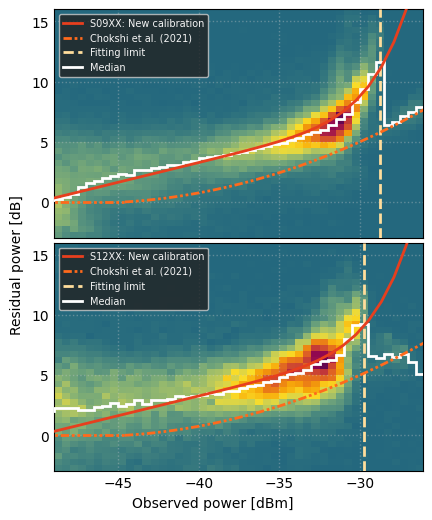

In [17]:
# rfe_cali_dir = Path("../passes/rfe_cal/20260714")
rfe_cali_dir = Path("../passes/rfe_cal/rfe_calibration_5hz/")
gain_files = sorted(rfe_cali_dir.glob("*gain_fit_new.json"))

# Select the two RFE calibration files
plot_files = [
    path
    for path in gain_files
    # if "S36YY_rf0YY" in path.stem or "S12XX_rf0XX" in path.stem
    if "S09XX_rf0XX" in path.stem or "S12XX_rf0XX" in path.stem
]

if len(plot_files) != 2:
    raise ValueError(
        f"Expected 2 matching gain files, but found {len(plot_files)}: "
        f"{[path.name for path in plot_files]}"
    )

# Chokshi et al. (2021) RFE calibration fit
rfe_polyfit_old = np.load("../passes/rfe_cal/original/rfe_gain_fit.npy")
gain_cal_old = np.poly1d(rfe_polyfit_old)

old_fit = np.poly1d(poly)
x_old = np.linspace(max(old_fit.roots), -25, num=100)
y_old = old_fit(x_old)

data_xlims = (-50, -15)
data_ylims = (-10, 15)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(4.5, 5.4),
    sharex=True,
)

for ax, gain_file in zip(axes, plot_files):
    with gain_file.open("r") as file:
        rfe = json.load(file)

    pass_data = np.asarray(rfe["tile_pass_data"])
    pass_resi = np.asarray(rfe["pass_resi"])
    pass_hpx = np.asarray(rfe["hpx_idx"])

    # Basic mask
    mask_crop = (
        np.isfinite(pass_data)
        & np.isfinite(pass_resi)
        & (pass_data >= data_xlims[0])
        & (pass_resi >= data_ylims[0])
    )

    # Data to be fit
    x_data = pass_data[mask_crop]
    y_data = pass_resi[mask_crop]

    bw = 0.5
    x_data_be = np.arange(
        data_xlims[0],
        np.ceil(x_data.max()) + bw,
        bw,
    )
    y_data_be = np.arange(
        data_ylims[0],
        np.ceil(y_data.max()) + bw,
        bw,
    )

    x_data_median, _, _ = binned_statistic(
        x_data,
        y_data,
        statistic="median",
        bins=x_data_be,
    )
    x_data_bc = 0.5 * (x_data_be[:-1] + x_data_be[1:])

    # Histogram the data to determine the fitting threshold
    x_data_hist_norm, _ = np.histogram(
        x_data,
        bins=x_data_be,
        density=True,
    )

    cut_candidates = np.flatnonzero(
        (x_data_hist_norm < 0.02)
        & (x_data_bc > -32.5)
    )
    if cut_candidates.size == 0:
        raise ValueError(
            f"Could not determine a fitting limit for {gain_file.name}"
        )

    bc_cut = cut_candidates[0]

    # Fit the monotonic calibration model
    Nc = 10
    highval = 20

    x0 = np.zeros(Nc)
    x0[-1] = 0.2

    Imatr = get_Imatr(
        scale_to_unit(
            x_data_bc[:bc_cut],
            data_xlims[0],
            x_data.max(),
        ),
        Nc=Nc,
    )
    y_fit = x_data_median[:bc_cut]

    soln = minimize(
        proxy_objective,
        x0=x0,
        bounds=Nc * [[0, highval]],
    )
    deriv_coeffs_best = np.cumsum(soln.x)

    u_grid = np.linspace(0, 1, 32)
    Imatr_grid = get_Imatr(u_grid, Nc=Nc)
    y_grid = Imatr_grid[:, 1:] @ deriv_coeffs_best
    x_grid = scale_from_unit(
        u_grid,
        data_xlims[0],
        x_data.max(),
    )

    # Plot the 2D histogram
    ax.hist2d(
        x_data,
        y_data,
        bins=[x_data_be, y_data_be],
        cmap=prd_paper,
    )

    ax.plot(
        x_grid,
        y_grid,
        color="#E73F1E",
        lw=2,
        label=f"{gain_file.stem[:5]}: New calibration",
        zorder=7,
    )

    ax.plot(
        x_old,
        y_old,
        color="#FF6A1C",
        lw=2,
        ls=(0, (3, 1, 1, 1, 1, 1)),
        label="Chokshi et al. (2021)",
        zorder=6
    )
    ax.plot(
        [data_xlims[0], x_old[0]],
        [0, 0],
        color="#FF6A1C",
        lw=2,
        ls=(0, (3, 1, 1, 1, 1, 1)),
        zorder=6,
    )

    ax.axvline(
        x_data_bc[bc_cut],
        color="#FFDD9C",
        ls="--",
        lw=2,
        label="Fitting limit",
        zorder=4,
    )

    ax.stairs(
        x_data_median,
        x_data_be,
        color="white",
        lw=2,
        label="Median",
        zorder=5,
    )

    ax.tick_params(axis="both", length=0)
    ax.grid(
        color="#cccccc",
        alpha=0.36,
        lw=1,
        ls=":",
    )
    ax.set_xlim(-49, -26.1)
    ax.set_ylim(-3, 16)
    ax.set_yticks([0, 5, 10, 15])

    ax.legend(
        loc="upper left",
        facecolor="#222",
        labelcolor="whitesmoke",
        fontsize=7,
    )

fig.supxlabel("Observed power [dBm]", fontsize=10, y=0.045)
fig.supylabel("Residual power [dB]", fontsize=10, x=0.05)

fig.tight_layout()
fig.subplots_adjust(hspace=0.02)
# plt.savefig(f"../data/plots/rfe_gain_new.pdf", bbox_inches="tight", pad_inches=0.03,)
plt.savefig(f"../data/plots/rfe_gain_new_5hz.pdf", bbox_inches="tight", pad_inches=0.03,)
# plt.savefig(f"../data/plots/rfe_gain_new_5hz_p08.pdf", bbox_inches="tight", pad_inches=0.03,)
plt.show()